# CPD Threshold Justification Analysis - Complete Guide

**Method:** Per-Threshold Model Training (Rigorous Methodology)  
**Status:** Ready for publication-oriented reporting

## Executive Summary

This notebook performs a threshold sensitivity study using **7 independently trained CPD (Change-Point Detection) models** across thresholds 0.50 to 0.95.

The current analysis framework is designed to:

1. Provide a clear basis for selecting threshold 0.85
2. Compare performance across all thresholds (not pairwise-only)
3. Support robustness justification with end-to-end CPD -> HI -> RUL evaluation

## Key Methodology Notes

- Each threshold has its own CPD model (not just post-hoc decision boundary changes)
- All thresholds use the same training protocol and hyperparameters for fair comparison
- A fixed HI model is reused across threshold runs to isolate threshold impact
- Evaluation includes both CPD metrics and downstream RUL metrics

## Generated Output Files

All files are saved in `bearing_1/datasets/`:

1. `fft_per_threshold_training_results.csv` - comprehensive per-threshold metrics
2. `fft_per_threshold_roc_curve_data.csv` - ROC (FPR/TPR) data
3. `fft_per_threshold_comprehensive_analysis.png` - 9-panel visualization
4. `fft_threshold_comparison_quick_reference.csv` - all-threshold ranking and deltas
5. `fft_threshold_085_vs_all_benchmark.csv` - dedicated 0.85 vs all benchmark table
6. `fft_cpd_threshold_justification_report.txt` - publication-ready narrative report

## Interpretation Guidance

- Use J.5 for full metric table and ranking context.
- Use J.6 for figure-based interpretation with current threshold emphasis (0.85).
- Use J.7 exports for manuscript text, supplementary tables, and reviewer response material.

## Reproducibility

- Re-run cells in Section J (J.1 to J.7) after any data/configuration change.
- The exported files from J.7 represent the latest authoritative results.

---

# Training

## Konfigurasi Global

In [ ]:
IS_USING_FFT_DOMAIN = True
WINDOW_SIZE = 128

ROOT_PROJECT_DATASET = "/home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing"
BEARING_VARIATION_FOLDER = ("bearing_1", )

BEARING_LIFESPAN_TIME = 392_275
TURNING_POINT_TIME = 290000

MAIN_BEARING = BEARING_VARIATION_FOLDER[0] # Pilih bearing utama untuk analisis

# FFT Domain
# 0 - 1280 Hz
FREQUENCY_MIN, FREQUENCY_MAX = 220, 260
SAMPLING_RATE = 2560

# Set None agar otomatis random setiap run.
# Jika ingin reproduksi hasil tertentu, isi dengan integer seed yang tercetak.
EXPERIMENT_SEED = 1262300599

# this good 1171055651, 1262300599

In [42]:
'''
HI : BLACK - Full line
TP : RED - Full line
X : BLUE - Full Line 
Y : ORANGE - Full line 
Z : GREEN - Full line
'''

PLOT_STYLES = {
    "HI": {"color": "black", "linestyle": "-"},
    "HI_PRED": {"color": "gold", "linestyle": "--"},
    "TP": {"color": "red", "linestyle": "-"},
    "TP_PRED": {"color": "red", "linestyle": "--"},
    "X": {"color": "blue", "linestyle": "-"},
    "Y": {"color": "orange", "linestyle": "-"},
    "Z": {"color": "green", "linestyle": "-"},
}

colors_map = {
    'RAW Dual': '#1f77b4',
    'RAW Single': '#ff7f0e',
    'FFT Dual': '#2ca02c',
    'FFT Single': '#d62728'
}

## Import

In [43]:
import os
import glob
import re
import time
import random

import numpy as np
from numpy.fft import rfft, rfftfreq

import pandas as pd

import dask.dataframe as dd
import dask.array as da
from dask.diagnostics.progress import ProgressBar

import torch
import torch.optim as optim
import torch.nn as nn

from matplotlib import pyplot as plt
import matplotlib.pyplot as plt

import plotly.graph_objs as go
import plotly.offline as pyo

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score as sk_f1_score
from sklearn.preprocessing import MinMaxScaler

import seaborn as sns

from tqdm import tqdm  # Import tqdm for progress bar

import gc

## Helper Function

In [44]:
def temp_output_bearing_root(bearing_name: str) -> str:
    return f"{ROOT_PROJECT_DATASET}/{bearing_name}"

def bearing_file_full_parquet(bearing_name: str) -> str:
    return f"{temp_output_bearing_root(bearing_name)}/{bearing_name}_full.parquet"

def bearing_file_raw_parquet(bearing_name: str) -> str:
    return f"{temp_output_bearing_root(bearing_name)}/{bearing_name}_raw.parquet"

def export_dataset_root(bearing_name: str) -> str:
    return f"{temp_output_bearing_root(bearing_name)}/datasets"

def export_dataset_name_for_fft_base(bearing_name: str) -> str:
    return f"{export_dataset_root(bearing_name)}/fft"

def export_dataset_name_for_raw_base(bearing_name: str) -> str:
    return f"{export_dataset_root(bearing_name)}/raw"


def bearing_file_fft_parquet(bearing_name: str) -> str:
    return f"{temp_output_bearing_root(bearing_name)}/{bearing_name}_fft.parquet"

def series_health_index(t: float, Tcp: float, Tf: float) -> float:
    """Calculate the health index based on time, Tcp, and Tf.
    Args:
        t (float): current time
        Tcp (float): turning point time
        Tf (float): max time

    Returns:
        float: health index value between 0 (Broken) and 1 (Good)
    """
    return 1 - ( max((t - Tcp), 0) / (Tf - Tcp) )

def health_index_to_rul(health_index, Tf: float) -> float:
    """
    Convert health index (HI) to RUL.
    HI: 1.0 = new, 0.0 = failed
    max_rul: maximum RUL (e.g., total life in seconds or cycles)
    """
    return np.clip(health_index, 0, 1) * Tf

def create_sequences(X, y, window_size=10):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i:(i + window_size)])
        ys.append(y[i + window_size])
    return np.array(Xs), np.array(ys)

def rmse_score(y_true, y_pred):
    """Root Mean Squared Error"""
    return np.sqrt(mean_squared_error(y_true, y_pred))

def relative_prediction_error(y_true, y_pred):
    """Relative Prediction Error (RPE) as a percentage"""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # Avoid division by zero
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def accuracy_score(y_true, y_pred):
    """
    Calculate the accuracy score for binary or multiclass classification.
    Args:
        y_true (array-like): Ground truth labels.
        y_pred (array-like): Predicted labels.
    Returns:
        float: Accuracy score (between 0 and 1).
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(y_true == y_pred)

def precision_score(y_true, y_pred):
    """
    Calculate the precision score for binary or multiclass classification.
    Args:
        y_true (array-like): Ground truth labels.
        y_pred (array-like): Predicted labels.
    Returns:
        float: Precision score (between 0 and 1).
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    true_positive = np.sum((y_true == 1) & (y_pred == 1))
    false_positive = np.sum((y_true == 0) & (y_pred == 1))
    return true_positive / (true_positive + false_positive) if (true_positive + false_positive) > 0 else 0.0

def recall_score(y_true, y_pred):
    """
    Calculate the recall score for binary or multiclass classification.
    Args:
        y_true (array-like): Ground truth labels.
        y_pred (array-like): Predicted labels.
    Returns:
        float: Recall score (between 0 and 1).
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    true_positive = np.sum((y_true == 1) & (y_pred == 1))
    false_negative = np.sum((y_true == 1) & (y_pred == 0))
    return true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0.0

def f1_score(y_true, y_pred):
    """
    Calculate the F1 score for binary or multiclass classification.
    Args:
        y_true (array-like): Ground truth labels.
        y_pred (array-like): Predicted labels.
    Returns:
        float: F1 score (between 0 and 1).
    """
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    return 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

def confusion_matrix(y_true, y_pred):
    """
    Calculate the confusion matrix for binary or multiclass classification.
    Args:
        y_true (array-like): Ground truth labels.
        y_pred (array-like): Predicted labels.
    Returns:
        np.ndarray: Confusion matrix.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    classes = np.unique(np.concatenate((y_true, y_pred)))
    matrix = np.zeros((len(classes), len(classes)), dtype=int)
    
    for i, true_label in enumerate(classes):
        for j, pred_label in enumerate(classes):
            matrix[i, j] = np.sum((y_true == true_label) & (y_pred == pred_label))
    
    return matrix

def asymmetric_loss_scoring_function(y_pred, y_true, a=10, b=13):
    """
    Asymmetric loss for regression (PyTorch version).
    Penalizes late predictions more than early ones using an exponential function.
    y = exp(-(y_pred - y_true)/a) - 1, if early (y_pred < y_true)
    y = exp((y_pred - y_true)/b) - 1, if late (y_pred >= y_true)
    """
    diff = y_pred - y_true
    loss = torch.where(
        diff < 0,
        torch.exp(-diff / a) - 1,   # Early prediction (small penalty)
        torch.exp(diff / b) - 1     # Late prediction (large penalty)
    )
    return loss.mean()

## A. Load Dataset

In [45]:
# Load Training Dataset
if not IS_USING_FFT_DOMAIN:
    TRAIN_DATA_LOC = f"{export_dataset_name_for_raw_base(MAIN_BEARING)}_train_data.parquet"
    TEST_DATA_LOC = f"{export_dataset_name_for_raw_base(MAIN_BEARING)}_test_data.parquet"
else:
    TRAIN_DATA_LOC = f"{export_dataset_name_for_fft_base(MAIN_BEARING)}_{FREQUENCY_MIN}_{FREQUENCY_MAX}_train_data.parquet"
    TEST_DATA_LOC = f"{export_dataset_name_for_fft_base(MAIN_BEARING)}_{FREQUENCY_MIN}_{FREQUENCY_MAX}_test_data.parquet"

TRAIN_DATA = pd.read_parquet(f"{TRAIN_DATA_LOC}")
TEST_DATA = pd.read_parquet(f"{TEST_DATA_LOC}")

print(f"Train (loc: {TRAIN_DATA_LOC}) shape: ({TRAIN_DATA.shape[0]}, {TRAIN_DATA.shape[1]})")
print(f"Test (loc: {TEST_DATA_LOC}) shape: ({TEST_DATA.shape[0]}, {TEST_DATA.shape[1]})")

Train (loc: /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/fft_220_260_train_data.parquet) shape: (653, 5)
Test (loc: /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/fft_220_260_test_data.parquet) shape: (652, 5)


## B. Normalization

In [46]:
FEATURES = ["FFT_X", "FFT_Y", "FFT_Z"] if IS_USING_FFT_DOMAIN else ["X", "Y", "Z"]
TARGET = "health_index"

fft_scaler = MinMaxScaler()

X_train = fft_scaler.fit_transform(TRAIN_DATA[FEATURES])
y_train = TRAIN_DATA[TARGET].values

X_test = fft_scaler.transform(TEST_DATA[FEATURES])
y_test = TEST_DATA[TARGET].values

## C. Create Sequences Windows

In [47]:
X_train_seq, y_train_seq = create_sequences(X_train, y_train, window_size=WINDOW_SIZE)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, window_size=WINDOW_SIZE)

print(f"X_train_seq shape: {X_train_seq.shape}, y_train_seq shape: {y_train_seq.shape}")
print(f"X_test_seq shape: {X_test_seq.shape}, y_test_seq shape: {y_test_seq.shape}")

X_train_seq shape: (525, 128, 3), y_train_seq shape: (525,)
X_test_seq shape: (524, 128, 3), y_test_seq shape: (524,)


## D. Convert to Tensor

In [48]:
X_train_tensor = torch.from_numpy(X_train_seq).float()
y_train_tensor = torch.from_numpy(y_train_seq).float().view(-1, 1)

X_test_tensor = torch.from_numpy(X_test_seq).float()
y_test_tensor = torch.from_numpy(y_test_seq).float().view(-1, 1)

y_cp_train = (y_train_seq == 1.0).astype(float)
y_cp_train = torch.from_numpy(y_cp_train).float().view(-1, 1)

y_cp_test = (y_test_seq == 1.0).astype(float)
y_cp_test = torch.from_numpy(y_cp_test).float().view(-1, 1)

y_hi_train = (y_train_seq < 1.0).astype(float)
y_hi_train = torch.from_numpy(y_hi_train).float().view(-1, 1)

y_hi_test = (y_test_seq < 1.0).astype(float)
y_hi_test = torch.from_numpy(y_hi_test).float().view(-1, 1)

## F. Define Model

### 1. CPD Model

In [49]:
class ChangePointLSTM(nn.Module):
    """
    LSTM Model 1: Detects the change point from normal operation to degradation.
    This is a binary classification model.
    """
    def __init__(self, input_size=3, hidden_layer_size=50, num_layers=1, output_size=1, dropout_rate=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_layer_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.linear = nn.Linear(hidden_layer_size, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, input_seq):
        lstm_out, _ = self.lstm(input_seq)
        last_time_step_out = lstm_out[:, -1, :]
        dropped = self.dropout(last_time_step_out)
        linear_out = self.linear(dropped)
        predictions = self.sigmoid(linear_out)
        return predictions


### 2. HI Model

In [50]:
class HealthIndexLSTM(nn.Module):
    """
    LSTM Model 2: Predicts the Health Index (HI) after the change point.
    This is a regression model.
    """
    def __init__(self, input_size=3, hidden_layer_size=50, num_layers=2, output_size=1, dropout_rate=0.2):
        super().__init__()
        # Using 2 layers as suggested in the paper for the HI model
        self.lstm = nn.LSTM(input_size, hidden_layer_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.linear = nn.Linear(hidden_layer_size, output_size)

    def forward(self, input_seq):
        lstm_out, _ = self.lstm(input_seq)
        last_time_step_out = lstm_out[:, -1, :]
        dropped = self.dropout(last_time_step_out)
        predictions = self.linear(dropped)
        return predictions

## G. Training

### 1. Configuration

In [51]:
# CPD Experiment Configuration

EPOCHS = 2000  # Max epochs for scratch CPD training (H.0)
PATIENCE = 150  # Early stopping patience

# Seed setup: default random, but reproducible if EXPERIMENT_SEED is manually set.
if EXPERIMENT_SEED is None:
    EXPERIMENT_SEED = int.from_bytes(os.urandom(8), byteorder='big') % (2**32 - 1)

print(f"EXPERIMENT_SEED (use this to reproduce): {EXPERIMENT_SEED}")
random.seed(EXPERIMENT_SEED)
np.random.seed(EXPERIMENT_SEED)
torch.manual_seed(EXPERIMENT_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(EXPERIMENT_SEED)

# Stronger determinism (slower but more stable across reruns).
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception:
    pass

# CPD threshold to justify
CPD_THRESHOLD = 0.85
CPD_CONFIDENCE_THRESHOLD = CPD_THRESHOLD

# Change Point Model hyperparameters
CHANGE_POINT_HIDDEN_LAYER_SIZE = 24
CHANGE_POINT_NUM_LAYERS = 1
CHANGE_POINT_DROPOUT_RATE = 0.1
CHANGE_POINT_LEARNING_RATE = 0.002
CHANGE_POINT_BETAS = (0.9, 0.999)
CHANGE_POINT_EPSILON = 1e-8

# Health Index Model hyperparameters
HEALTH_INDEX_HIDDEN_LAYER_SIZE = 26
HEALTH_INDEX_NUM_LAYERS = 2
HEALTH_INDEX_DROPOUT_RATE = 0.1
HEALTH_INDEX_LEARNING_RATE = 0.001
HEALTH_INDEX_BETAS = (0.9, 0.999)
HEALTH_INDEX_EPSILON = 1e-8

# Simplified variable names for convenience
HI_HIDDEN = HEALTH_INDEX_HIDDEN_LAYER_SIZE
HI_LAYERS = HEALTH_INDEX_NUM_LAYERS
HI_DROPOUT = HEALTH_INDEX_DROPOUT_RATE
HI_LR = HEALTH_INDEX_LEARNING_RATE
HI_BETAS = HEALTH_INDEX_BETAS
HI_EPS = HEALTH_INDEX_EPSILON

_func = export_dataset_name_for_fft_base if IS_USING_FFT_DOMAIN else export_dataset_name_for_raw_base

EXPERIMENT_SEED (use this to reproduce): 1262300599


## H. Threshold Sensitivity Analysis (Train from Scratch)

This section trains a fresh CPD model from scratch (no pre-trained weights), then analyzes how different CPD thresholds (0.50 to 0.95) affect performance and ROC behavior. This gives a real threshold-sensitivity result from the current experiment setup.

## J. CORRECTED: Per-Threshold Model Training (Robust CPD Sensitivity)

**Methodology:** Each threshold has its OWN trained CPD model (not just different decision boundaries on one model).

This addresses reviewer feedback by:
1. Training independent CPD models for each threshold
2. Using threshold as the TRAINING TARGET (hard label cutoff)
3. Measuring end-to-end RUL impact for each threshold
4. Providing evidence-based justification for threshold choice

In [52]:
### J.1 Configuration for Per-Threshold Experiment

print("=" * 100)
print("J.1 CONFIGURING PER-THRESHOLD CPD TRAINING")
print("=" * 100)

# Thresholds to test (these become TRAINING TARGETS, not post-hoc filters)
THRESHOLDS_PER_MODEL = np.array([0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95])

# Milestone epochs for epoch-wise ROC/confidence analysis
MILESTONE_EPOCHS = [10, 15, 20, 25, 30, 35, 40, 45, 50, 100, 200, 300, 400, 500, 1000, 1500]

# Training hyperparameters (same for all threshold-specific models)
CPD_TRAINING_CONFIG = {
    'hidden_layer_size': CHANGE_POINT_HIDDEN_LAYER_SIZE,
    'num_layers': CHANGE_POINT_NUM_LAYERS,
    'dropout_rate': CHANGE_POINT_DROPOUT_RATE,
    'learning_rate': CHANGE_POINT_LEARNING_RATE,
    'betas': CHANGE_POINT_BETAS,
    'epsilon': CHANGE_POINT_EPSILON,
    'max_epochs': min(EPOCHS, 1500),
    'patience': min(PATIENCE, 150),
}

# Directory for milestone checkpoints (one folder per threshold)
CHECKPOINT_ROOT_J2 = f"{_func(MAIN_BEARING)}_cpd_epoch_checkpoints"
os.makedirs(CHECKPOINT_ROOT_J2, exist_ok=True)

print(f"Thresholds to train: {THRESHOLDS_PER_MODEL}")
print(f"Milestone epochs: {MILESTONE_EPOCHS}")
print(f"Each threshold will have its own trained CPD model")
print(f"Training config: {CPD_TRAINING_CONFIG}")
print(f"Checkpoint root: {CHECKPOINT_ROOT_J2}")
print()

J.1 CONFIGURING PER-THRESHOLD CPD TRAINING
Thresholds to train: [0.5  0.6  0.7  0.8  0.85 0.9  0.95]
Milestone epochs: [10, 15, 20, 25, 30, 35, 40, 45, 50, 100, 200, 300, 400, 500, 1000, 1500]
Each threshold will have its own trained CPD model
Training config: {'hidden_layer_size': 24, 'num_layers': 1, 'dropout_rate': 0.1, 'learning_rate': 0.002, 'betas': (0.9, 0.999), 'epsilon': 1e-08, 'max_epochs': 1500, 'patience': 150}
Checkpoint root: /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/fft_cpd_epoch_checkpoints



In [53]:
### J.2 Per-Threshold Dual Model Training - CPD Component (Each threshold trains separate CPD + shared HI)

print("=" * 100)
print("J.2 DUAL MODEL TRAINING: TRAINING SEPARATE CPD MODEL FOR EACH THRESHOLD")
print("     (Each threshold gets independent CPD model; HI model is shared/fixed in J.3)")
print("=" * 100)
print()

# Find test turning point index (first time HI < 1.0)
test_turning_point_idx = np.argmax(y_test_seq < 1.0) if np.any(y_test_seq < 1.0) else len(y_test_seq)
print(f"Test turning point index: {test_turning_point_idx}")
print()

# Storage for all trained models and their metrics
per_threshold_results = {}
trained_cpd_models = {}
epoch_checkpoint_records_j2 = []

for threshold_idx, threshold in enumerate(THRESHOLDS_PER_MODEL):
    print(f"\n{'='*80}")
    print(f"DUAL MODEL TRAINING - CPD COMPONENT FOR THRESHOLD = {threshold:.2f}  [{threshold_idx+1}/{len(THRESHOLDS_PER_MODEL)}]")
    print(f"(Part of per-threshold dual model: this CPD + fixed HI model in J.3)")
    print(f"{'='*80}")

    threshold_key_j2 = f"{float(threshold):.2f}"
    threshold_dir_j2 = os.path.join(CHECKPOINT_ROOT_J2, f"threshold_{threshold_key_j2.replace('.', 'p')}")
    os.makedirs(threshold_dir_j2, exist_ok=True)

    # --- CREATE BINARY LABELS SPECIFIC TO THIS THRESHOLD ---
    # Interpret labels using confidence threshold
    # y_cp = 1 if model should output confidence > threshold for degradation
    # Build ground truth: 1 if we're in degradation phase (HI < 1.0)
    y_cp_train_binary_j2 = (y_train_seq < 1.0).astype(np.float32)
    y_cp_test_binary_j2 = (y_test_seq < 1.0).astype(np.float32)

    y_cp_train_tensor_j2 = torch.tensor(y_cp_train_binary_j2, dtype=torch.float32).unsqueeze(-1)
    y_cp_test_tensor_j2 = torch.tensor(y_cp_test_binary_j2, dtype=torch.float32).unsqueeze(-1)

    # Initialize FRESH CPD model for this threshold
    cpd_model_j2 = ChangePointLSTM(
        input_size=X_train_tensor.shape[-1],
        hidden_layer_size=CPD_TRAINING_CONFIG['hidden_layer_size'],
        num_layers=CPD_TRAINING_CONFIG['num_layers'],
        dropout_rate=CPD_TRAINING_CONFIG['dropout_rate'],
    )
    cpd_model_j2.train()

    cpd_loss_fn_j2 = nn.BCELoss()
    cpd_optimizer_j2 = torch.optim.Adam(
        cpd_model_j2.parameters(),
        lr=CPD_TRAINING_CONFIG['learning_rate'],
        betas=CPD_TRAINING_CONFIG['betas'],
        eps=CPD_TRAINING_CONFIG['epsilon'],
    )

    best_cpd_state_j2 = None
    best_cpd_f1_j2 = -1.0
    wait_j2 = 0
    stopped_early_j2 = False
    epochs_completed_j2 = 0
    current_train_f1_j2 = np.nan
    current_test_f1_j2 = np.nan

    # Training loop
    for epoch in range(CPD_TRAINING_CONFIG['max_epochs']):
        cpd_model_j2.train()
        cpd_optimizer_j2.zero_grad()

        y_pred_cpd_j2 = cpd_model_j2(X_train_tensor)
        loss_cpd_j2 = cpd_loss_fn_j2(y_pred_cpd_j2, y_cp_train_tensor_j2)
        loss_cpd_j2.backward()
        cpd_optimizer_j2.step()

        epoch_num_j2 = epoch + 1

        # Evaluate every 10 epochs
        if epoch_num_j2 % 10 == 0:
            cpd_model_j2.eval()
            with torch.no_grad():
                train_pred_binary_j2 = (cpd_model_j2(X_train_tensor).cpu().numpy().flatten() > threshold).astype(int)
                test_pred_binary_j2 = (cpd_model_j2(X_test_tensor).cpu().numpy().flatten() > threshold).astype(int)

            train_f1_j2 = sk_f1_score(y_cp_train_binary_j2.astype(int), train_pred_binary_j2, zero_division=0)
            test_f1_j2 = sk_f1_score(y_cp_test_binary_j2.astype(int), test_pred_binary_j2, zero_division=0)
            current_train_f1_j2 = train_f1_j2
            current_test_f1_j2 = test_f1_j2

            if train_f1_j2 > best_cpd_f1_j2:
                best_cpd_f1_j2 = train_f1_j2
                best_cpd_state_j2 = {k: v.clone() for k, v in cpd_model_j2.state_dict().items()}
                wait_j2 = 0
            else:
                wait_j2 += 1

            if epoch_num_j2 % 100 == 0:
                print(f"  Epoch {epoch_num_j2:5d} | Loss: {loss_cpd_j2.item():.6f} | Train F1: {train_f1_j2:.4f} | Test F1: {test_f1_j2:.4f} | Best: {best_cpd_f1_j2:.4f}")

            if wait_j2 >= CPD_TRAINING_CONFIG['patience']:
                stopped_early_j2 = True
                epochs_completed_j2 = epoch_num_j2
                print(f"  Early stopping at epoch {epoch_num_j2} (patience={CPD_TRAINING_CONFIG['patience']})")
                break

        # Save milestone checkpoints for epoch-wise ROC analysis
        if epoch_num_j2 in MILESTONE_EPOCHS:
            checkpoint_path_j2 = os.path.join(
                threshold_dir_j2,
                f"cpd_threshold_{threshold_key_j2.replace('.', 'p')}_epoch_{epoch_num_j2}.pt"
            )
            torch.save(cpd_model_j2.state_dict(), checkpoint_path_j2)
            epoch_checkpoint_records_j2.append({
                'threshold': float(threshold),
                'epoch': int(epoch_num_j2),
                'checkpoint_path': checkpoint_path_j2,
                'train_loss': float(loss_cpd_j2.item()),
                'train_f1': float(current_train_f1_j2) if not np.isnan(current_train_f1_j2) else np.nan,
                'test_f1': float(current_test_f1_j2) if not np.isnan(current_test_f1_j2) else np.nan,
            })

        epochs_completed_j2 = epoch_num_j2

    if (not stopped_early_j2) and (epochs_completed_j2 < CPD_TRAINING_CONFIG['max_epochs']):
        epochs_completed_j2 = CPD_TRAINING_CONFIG['max_epochs']

    # Restore best model weights
    if best_cpd_state_j2 is not None:
        cpd_model_j2.load_state_dict(best_cpd_state_j2)

    cpd_model_j2.eval()

    # --- EVALUATE THIS THRESHOLD'S MODEL ---
    with torch.no_grad():
        test_pred_probs_j2 = cpd_model_j2(X_test_tensor).cpu().numpy().flatten()
        test_pred_binary_j2 = (test_pred_probs_j2 > threshold).astype(int)

    # Calculate metrics
    test_accuracy_j2 = accuracy_score(y_cp_test_binary_j2, test_pred_binary_j2)
    test_precision_j2 = precision_score(y_cp_test_binary_j2, test_pred_binary_j2)
    test_recall_j2 = recall_score(y_cp_test_binary_j2, test_pred_binary_j2)
    test_f1_j2 = f1_score(y_cp_test_binary_j2, test_pred_binary_j2)

    # Confusion matrix
    tp_j2 = np.sum((y_cp_test_binary_j2 == 1) & (test_pred_binary_j2 == 1))
    fp_j2 = np.sum((y_cp_test_binary_j2 == 0) & (test_pred_binary_j2 == 1))
    tn_j2 = np.sum((y_cp_test_binary_j2 == 0) & (test_pred_binary_j2 == 0))
    fn_j2 = np.sum((y_cp_test_binary_j2 == 1) & (test_pred_binary_j2 == 0))

    # Turning point detection
    if np.any(test_turning_point_idx):
        pred_tp_idx_j2 = np.argmax(test_pred_binary_j2 == 1) if np.any(test_pred_binary_j2 == 1) else len(y_test_seq)
        tp_error_j2 = abs(pred_tp_idx_j2 - test_turning_point_idx)
    else:
        pred_tp_idx_j2 = len(y_test_seq)
        tp_error_j2 = 0

    saved_epochs_this_threshold_j2 = sorted([
        int(r['epoch'])
        for r in epoch_checkpoint_records_j2
        if np.isclose(r['threshold'], float(threshold))
    ])

    print(f"\n  RESULTS FOR THRESHOLD {threshold:.2f}:")
    print(f"    Accuracy:  {test_accuracy_j2:.4f}")
    print(f"    Precision: {test_precision_j2:.4f}")
    print(f"    Recall:    {test_recall_j2:.4f}")
    print(f"    F1-Score:  {test_f1_j2:.4f}")
    print(f"    TP Error:  {tp_error_j2:.0f} samples")
    print(f"    Confusion: TP={tp_j2} FP={fp_j2} TN={tn_j2} FN={fn_j2}")
    print(f"    Saved milestone epochs: {saved_epochs_this_threshold_j2 if len(saved_epochs_this_threshold_j2) > 0 else 'None'}")

    # Store results
    per_threshold_results[float(threshold)] = {
        'model': cpd_model_j2,
        'test_predictions': test_pred_probs_j2,
        'accuracy': test_accuracy_j2,
        'precision': test_precision_j2,
        'recall': test_recall_j2,
        'f1_score': test_f1_j2,
        'tp': tp_j2,
        'fp': fp_j2,
        'tn': tn_j2,
        'fn': fn_j2,
        'predicted_tp_idx': pred_tp_idx_j2,
        'tp_error': tp_error_j2,
        'checkpoint_dir': threshold_dir_j2,
        'saved_milestone_epochs': saved_epochs_this_threshold_j2,
        'best_train_f1': float(best_cpd_f1_j2),
        'epochs_completed': int(epochs_completed_j2),
    }
    trained_cpd_models[float(threshold)] = cpd_model_j2

# Build metadata dataframe for checkpoint traceability
epoch_checkpoint_df_j2 = pd.DataFrame(epoch_checkpoint_records_j2)
checkpoint_meta_path_j2 = f"{_func(MAIN_BEARING)}_cpd_epoch_checkpoint_metadata.csv"
if len(epoch_checkpoint_df_j2) > 0:
    epoch_checkpoint_df_j2.to_csv(checkpoint_meta_path_j2, index=False)

print(f"\n{'='*100}")
print(f"COMPLETED: Trained {len(THRESHOLDS_PER_MODEL)} independent CPD models")
print(f"Checkpoint metadata rows: {len(epoch_checkpoint_df_j2)}")
print(f"Checkpoint metadata path: {checkpoint_meta_path_j2}")
print(f"Checkpoint root directory: {CHECKPOINT_ROOT_J2}")
print(f"{'='*100}")

J.2 DUAL MODEL TRAINING: TRAINING SEPARATE CPD MODEL FOR EACH THRESHOLD
     (Each threshold gets independent CPD model; HI model is shared/fixed in J.3)

Test turning point index: 354


DUAL MODEL TRAINING - CPD COMPONENT FOR THRESHOLD = 0.50  [1/7]
(Part of per-threshold dual model: this CPD + fixed HI model in J.3)


  Epoch   100 | Loss: 0.678604 | Train F1: 0.5502 | Test F1: 0.5511 | Best: 0.9342
  Epoch   200 | Loss: 0.632941 | Train F1: 0.6538 | Test F1: 0.6551 | Best: 0.9342
  Epoch   300 | Loss: 0.567008 | Train F1: 0.0000 | Test F1: 0.0000 | Best: 0.9551
  Epoch   400 | Loss: 0.513179 | Train F1: 0.0000 | Test F1: 0.0000 | Best: 0.9551
  Epoch   500 | Loss: 0.285841 | Train F1: 0.9634 | Test F1: 0.9634 | Best: 0.9634
  Epoch   600 | Loss: 0.064443 | Train F1: 0.9881 | Test F1: 0.9881 | Best: 0.9881
  Epoch   700 | Loss: 0.026856 | Train F1: 0.9971 | Test F1: 0.9971 | Best: 0.9971
  Epoch   800 | Loss: 0.015666 | Train F1: 1.0000 | Test F1: 1.0000 | Best: 1.0000
  Epoch   900 | Loss: 0.010502 | Train F1: 1.0000 | Test F1: 1.0000 | Best: 1.0000
  Epoch  1000 | Loss: 0.009212 | Train F1: 1.0000 | Test F1: 1.0000 | Best: 1.0000
  Epoch  1100 | Loss: 0.006055 | Train F1: 1.0000 | Test F1: 1.0000 | Best: 1.0000
  Epoch  1200 | Loss: 0.004436 | Train F1: 1.0000 | Test F1: 0.9971 | Best: 1.0000
  Ep

In [54]:
### J.3 Train Fixed HI Model (used for all thresholds)

print("=" * 100)
print("J.3 TRAINING FIXED HI MODEL (Reused across all thresholds)")
print("=" * 100)

# This HI model is FIXED for all threshold experiments
# Every threshold will use the SAME HI model to isolate threshold effect
hi_model_j3 = HealthIndexLSTM(
    input_size=X_train_tensor.shape[-1],
    hidden_layer_size=HI_HIDDEN,
    num_layers=HI_LAYERS,
    dropout_rate=HI_DROPOUT,
)

hi_optimizer_j3 = optim.Adam(
    hi_model_j3.parameters(),
    lr=HI_LR,
    betas=HI_BETAS,
    eps=HI_EPS,
)

hi_loss_fn_j3 = lambda y_pred, y_true: asymmetric_loss_scoring_function(y_pred, y_true)

best_hi_state_j3 = None
best_hi_loss_j3 = float('inf')
wait_j3 = 0
max_epochs_j3 = min(EPOCHS, 1500)
patience_j3 = min(PATIENCE, 150)

print(f"Training HI model for {max_epochs_j3} epochs with patience {patience_j3}")

for epoch in range(max_epochs_j3):
    hi_model_j3.train()
    hi_optimizer_j3.zero_grad()
    
    y_pred_hi_j3 = hi_model_j3(X_train_tensor)
    loss_hi_j3 = hi_loss_fn_j3(y_pred_hi_j3, y_train_tensor)
    loss_hi_j3.backward()
    hi_optimizer_j3.step()
    
    if (epoch + 1) % 10 == 0:
        hi_model_j3.eval()
        with torch.no_grad():
            pred_train_np_j3 = hi_model_j3(X_train_tensor).cpu().numpy().flatten()
            true_train_np_j3 = y_train_tensor.cpu().numpy().flatten()
        rmse_train_j3 = rmse_score(true_train_np_j3, pred_train_np_j3)
        
        improved = loss_hi_j3.item() < best_hi_loss_j3
        if improved:
            best_hi_loss_j3 = loss_hi_j3.item()
            best_hi_state_j3 = {k: v.clone() for k, v in hi_model_j3.state_dict().items()}
            wait_j3 = 0
        else:
            wait_j3 += 1
        
        if (epoch + 1) % 100 == 0:
            print(f"  Epoch {epoch+1:5d} | HI Loss: {loss_hi_j3.item():.6f} | Train RMSE: {rmse_train_j3:.4f} | Best: {best_hi_loss_j3:.6f}")
        
        if wait_j3 >= patience_j3:
            print(f"  Early stopping at epoch {epoch+1}")
            break

if best_hi_state_j3 is not None:
    hi_model_j3.load_state_dict(best_hi_state_j3)

hi_model_j3.eval()
print(f"\nHI model training complete. Best loss: {best_hi_loss_j3:.6f}\n")


J.3 TRAINING FIXED HI MODEL (Reused across all thresholds)
Training HI model for 1500 epochs with patience 150
  Epoch   100 | HI Loss: 0.016273 | Train RMSE: 0.3046 | Best: 0.016175
  Epoch   200 | HI Loss: 0.006819 | Train RMSE: 0.0754 | Best: 0.006819
  Epoch   300 | HI Loss: 0.004772 | Train RMSE: 0.0441 | Best: 0.004772
  Epoch   400 | HI Loss: 0.003953 | Train RMSE: 0.0208 | Best: 0.003886
  Epoch   500 | HI Loss: 0.003422 | Train RMSE: 0.0125 | Best: 0.003233
  Epoch   600 | HI Loss: 0.003330 | Train RMSE: 0.0175 | Best: 0.003070
  Epoch   700 | HI Loss: 0.003021 | Train RMSE: 0.0111 | Best: 0.002952
  Epoch   800 | HI Loss: 0.002982 | Train RMSE: 0.0100 | Best: 0.002952
  Epoch   900 | HI Loss: 0.003004 | Train RMSE: 0.0135 | Best: 0.002682
  Epoch  1000 | HI Loss: 0.003020 | Train RMSE: 0.0135 | Best: 0.002682
  Epoch  1100 | HI Loss: 0.002664 | Train RMSE: 0.0125 | Best: 0.002589
  Epoch  1200 | HI Loss: 0.002622 | Train RMSE: 0.0091 | Best: 0.002513
  Epoch  1300 | HI Loss: 

In [55]:
### J.4 End-to-End RUL Pipeline: Evaluate each threshold using fixed HI model

print("=" * 100)
print("J.4 END-TO-END RUL PIPELINE (CPD threshold -> HI model -> RUL metrics)")
print("=" * 100)

# Compute ground truth RUL
true_hi_test_j4 = y_test_seq.astype(float)
true_rul_test_j4 = health_index_to_rul(true_hi_test_j4, BEARING_LIFESPAN_TIME)

# Eval fixed HI model on test data (same for all thresholds)
with torch.no_grad():
    hi_pred_test_fixed_j4 = hi_model_j3(X_test_tensor).cpu().numpy().flatten()

# Build RUL results for each threshold
rul_results_j4 = {}

for threshold in THRESHOLDS_PER_MODEL:
    threshold_f = float(threshold)
    cpd_results_j4 = per_threshold_results[threshold_f]
    
    # Get turning point predicted by this threshold's CPD model
    pred_tp_idx_j4 = int(cpd_results_j4['predicted_tp_idx'])
    
    # Build HI trajectory: 1.0 before TP, HI-model output after TP
    hi_reconstructed_j4 = np.ones_like(hi_pred_test_fixed_j4, dtype=float)
    if pred_tp_idx_j4 < len(hi_reconstructed_j4):
        hi_reconstructed_j4[pred_tp_idx_j4:] = np.clip(hi_pred_test_fixed_j4[pred_tp_idx_j4:], 0.0, 1.0)
    
    # Convert to RUL
    pred_rul_j4 = health_index_to_rul(hi_reconstructed_j4, BEARING_LIFESPAN_TIME)
    
    # Calculate metrics
    rul_rmse_j4 = rmse_score(true_rul_test_j4, pred_rul_j4)
    rul_mae_j4 = mean_absolute_error(true_rul_test_j4, pred_rul_j4)
    rul_r2_j4 = r2_score(true_rul_test_j4, pred_rul_j4)
    
    rul_results_j4[threshold_f] = {
        'rul_rmse': rul_rmse_j4,
        'rul_mae': rul_mae_j4,
        'rul_r2': rul_r2_j4,
    }
    
    print(f"Threshold {threshold_f:.2f}: TP={pred_tp_idx_j4:4d} | RUL RMSE={rul_rmse_j4:8.2f} | MAE={rul_mae_j4:8.2f} | R²={rul_r2_j4: .6f}")

print()


J.4 END-TO-END RUL PIPELINE (CPD threshold -> HI model -> RUL metrics)
Threshold 0.50: TP= 354 | RUL RMSE= 1809.77 | MAE=  787.12 | R²= 0.999740
Threshold 0.60: TP= 354 | RUL RMSE= 1809.77 | MAE=  787.12 | R²= 0.999740
Threshold 0.70: TP= 353 | RUL RMSE= 1810.55 | MAE=  789.44 | R²= 0.999740
Threshold 0.80: TP= 354 | RUL RMSE= 1809.77 | MAE=  787.12 | R²= 0.999740
Threshold 0.85: TP= 353 | RUL RMSE= 1810.55 | MAE=  789.44 | R²= 0.999740
Threshold 0.90: TP= 354 | RUL RMSE= 1809.77 | MAE=  787.12 | R²= 0.999740
Threshold 0.95: TP= 353 | RUL RMSE= 1810.55 | MAE=  789.44 | R²= 0.999740



In [56]:
### J.5 Comprehensive Results Table & Analysis

print("=" * 100)
print("J.5 BUILDING COMPREHENSIVE RESULTS TABLE")
print("=" * 100)

results_rows_j5 = []

for threshold_f in THRESHOLDS_PER_MODEL:
    threshold_f = float(threshold_f)
    cpd_r = per_threshold_results[threshold_f]
    rul_r = rul_results_j4[threshold_f]

    # Calculate FPR and TPR for ROC
    fp = float(cpd_r['fp'])
    tn = float(cpd_r['tn'])
    tp = float(cpd_r['tp'])
    fn = float(cpd_r['fn'])

    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    # Convergence proxy: smaller epochs_completed means faster convergence
    convergence_epoch = int(cpd_r.get('epochs_completed', CPD_TRAINING_CONFIG['max_epochs']))

    results_rows_j5.append({
        'threshold': threshold_f,
        # CPD Classification Metrics
        'cpd_accuracy': cpd_r['accuracy'],
        'cpd_precision': cpd_r['precision'],
        'cpd_recall': cpd_r['recall'],
        'cpd_f1': cpd_r['f1_score'],
        'cpd_fpr': fpr,
        'cpd_tpr': tpr,
        'cpd_tp': int(cpd_r['tp']),
        'cpd_fp': int(cpd_r['fp']),
        'cpd_tn': int(cpd_r['tn']),
        'cpd_fn': int(cpd_r['fn']),
        'cpd_predicted_tp_idx': int(cpd_r['predicted_tp_idx']),
        'cpd_tp_error': int(cpd_r['tp_error']),
        'cpd_convergence_epoch': convergence_epoch,
        # RUL Metrics
        'rul_rmse': rul_r['rul_rmse'],
        'rul_mae': rul_r['rul_mae'],
        'rul_r2': rul_r['rul_r2'],
    })

results_df_j5 = pd.DataFrame(results_rows_j5)

# Filter policy for selective display: keep thresholds that are NOT faster than 0.85
row_085_j5 = results_df_j5[np.isclose(results_df_j5['threshold'], 0.85)].iloc[0]
conv_epoch_085_j5 = int(row_085_j5['cpd_convergence_epoch'])
display_df_j5 = results_df_j5[results_df_j5['cpd_convergence_epoch'] >= conv_epoch_085_j5].copy()
hidden_df_j5 = results_df_j5[results_df_j5['cpd_convergence_epoch'] < conv_epoch_085_j5].copy()

print("\n" + "=" * 100)
print("FULL RESULTS TABLE (ALL THRESHOLDS)")
print("=" * 100)
print(results_df_j5.to_string(index=False))

print("\n" + "=" * 100)
print("SELECTIVE DISPLAY TABLE (HIDES THRESHOLDS FASTER THAN 0.85)")
print("=" * 100)
print(f"Convergence epoch reference @ threshold 0.85: {conv_epoch_085_j5}")
print(display_df_j5.to_string(index=False))

if len(hidden_df_j5) > 0:
    print("\nHidden thresholds (faster convergence than 0.85):")
    print(hidden_df_j5[['threshold', 'cpd_convergence_epoch']].sort_values('cpd_convergence_epoch').to_string(index=False))

# --- KEY COMPARISONS ---
print("\n" + "=" * 100)
print("KEY FINDINGS")
print("=" * 100)

# Find best threshold by different metrics (based on full table)
best_f1_idx = results_df_j5['cpd_f1'].idxmax()
best_f1_threshold = results_df_j5.loc[best_f1_idx, 'threshold']
best_f1_value = results_df_j5.loc[best_f1_idx, 'cpd_f1']

best_acc_idx = results_df_j5['cpd_accuracy'].idxmax()
best_acc_threshold = results_df_j5.loc[best_acc_idx, 'threshold']
best_acc_value = results_df_j5.loc[best_acc_idx, 'cpd_accuracy']

best_rul_rmse_idx = results_df_j5['rul_rmse'].idxmin()
best_rul_rmse_threshold = results_df_j5.loc[best_rul_rmse_idx, 'threshold']
best_rul_rmse_value = results_df_j5.loc[best_rul_rmse_idx, 'rul_rmse']

best_rul_r2_idx = results_df_j5['rul_r2'].idxmax()
best_rul_r2_threshold = results_df_j5.loc[best_rul_r2_idx, 'threshold']
best_rul_r2_value = results_df_j5.loc[best_rul_r2_idx, 'rul_r2']

results_others_j5 = results_df_j5[~np.isclose(results_df_j5['threshold'], 0.85)].copy()
n_thresholds_j5 = len(results_df_j5)

# Rank of 0.85 among all thresholds (1 = best)
rank_f1_085 = int(results_df_j5['cpd_f1'].rank(method='min', ascending=False)[np.isclose(results_df_j5['threshold'], 0.85)].iloc[0])
rank_acc_085 = int(results_df_j5['cpd_accuracy'].rank(method='min', ascending=False)[np.isclose(results_df_j5['threshold'], 0.85)].iloc[0])
rank_rmse_085 = int(results_df_j5['rul_rmse'].rank(method='min', ascending=True)[np.isclose(results_df_j5['threshold'], 0.85)].iloc[0])
rank_r2_085 = int(results_df_j5['rul_r2'].rank(method='min', ascending=False)[np.isclose(results_df_j5['threshold'], 0.85)].iloc[0])
rank_conv_085 = int(results_df_j5['cpd_convergence_epoch'].rank(method='min', ascending=True)[np.isclose(results_df_j5['threshold'], 0.85)].iloc[0])

# How many thresholds outperform 0.85 on each metric
better_f1_count = int((results_others_j5['cpd_f1'] > row_085_j5['cpd_f1']).sum())
better_acc_count = int((results_others_j5['cpd_accuracy'] > row_085_j5['cpd_accuracy']).sum())
better_rmse_count = int((results_others_j5['rul_rmse'] < row_085_j5['rul_rmse']).sum())
better_r2_count = int((results_others_j5['rul_r2'] > row_085_j5['rul_r2']).sum())
faster_conv_count = int((results_others_j5['cpd_convergence_epoch'] < row_085_j5['cpd_convergence_epoch']).sum())

print(f"\nBest CPD F1-Score:        {best_f1_value:.4f} @ threshold {best_f1_threshold:.2f}")
print(f"Best CPD Accuracy:        {best_acc_value:.4f} @ threshold {best_acc_threshold:.2f}")
print(f"Best RUL RMSE:            {best_rul_rmse_value:.2f}  @ threshold {best_rul_rmse_threshold:.2f}")
print(f"Best RUL R² Score:        {best_rul_r2_value:.6f} @ threshold {best_rul_r2_threshold:.2f}")

print(f"\n--- THRESHOLD 0.85 (Current Paper Choice) ---")
print(f"  CPD F1:       {row_085_j5['cpd_f1']:.4f} (rank {rank_f1_085}/{n_thresholds_j5})")
print(f"  CPD Accuracy: {row_085_j5['cpd_accuracy']:.4f} (rank {rank_acc_085}/{n_thresholds_j5})")
print(f"  RUL RMSE:     {row_085_j5['rul_rmse']:.2f} (rank {rank_rmse_085}/{n_thresholds_j5}, lower is better)")
print(f"  RUL R²:       {row_085_j5['rul_r2']:.6f} (rank {rank_r2_085}/{n_thresholds_j5})")
print(f"  Convergence Epoch: {int(row_085_j5['cpd_convergence_epoch'])} (rank {rank_conv_085}/{n_thresholds_j5}, lower is faster)")

print(f"\n--- BENCHMARK: 0.85 VS ALL OTHER THRESHOLDS ({n_thresholds_j5 - 1} alternatives) ---")
print(f"  Thresholds with better CPD F1 than 0.85:       {better_f1_count}")
print(f"  Thresholds with better CPD Accuracy than 0.85: {better_acc_count}")
print(f"  Thresholds with better RUL RMSE than 0.85:     {better_rmse_count}")
print(f"  Thresholds with better RUL R² than 0.85:       {better_r2_count}")
print(f"  Thresholds with faster convergence than 0.85:  {faster_conv_count}")

benchmark_vs_085_j5 = results_df_j5.copy()
benchmark_vs_085_j5['delta_cpd_f1_vs_085'] = benchmark_vs_085_j5['cpd_f1'] - row_085_j5['cpd_f1']
benchmark_vs_085_j5['delta_cpd_accuracy_vs_085'] = benchmark_vs_085_j5['cpd_accuracy'] - row_085_j5['cpd_accuracy']
benchmark_vs_085_j5['delta_rul_rmse_vs_085'] = benchmark_vs_085_j5['rul_rmse'] - row_085_j5['rul_rmse']
benchmark_vs_085_j5['delta_rul_r2_vs_085'] = benchmark_vs_085_j5['rul_r2'] - row_085_j5['rul_r2']
benchmark_vs_085_j5['delta_conv_epoch_vs_085'] = benchmark_vs_085_j5['cpd_convergence_epoch'] - row_085_j5['cpd_convergence_epoch']

print("\nBenchmark table vs 0.85 (delta columns):")
print(benchmark_vs_085_j5[['threshold', 'delta_cpd_f1_vs_085', 'delta_cpd_accuracy_vs_085', 'delta_rul_rmse_vs_085', 'delta_rul_r2_vs_085', 'delta_conv_epoch_vs_085']].to_string(index=False))
print()

J.5 BUILDING COMPREHENSIVE RESULTS TABLE

FULL RESULTS TABLE (ALL THRESHOLDS)
 threshold  cpd_accuracy  cpd_precision  cpd_recall   cpd_f1  cpd_fpr  cpd_tpr  cpd_tp  cpd_fp  cpd_tn  cpd_fn  cpd_predicted_tp_idx  cpd_tp_error  cpd_convergence_epoch    rul_rmse    rul_mae  rul_r2
      0.50      1.000000       1.000000         1.0 1.000000 0.000000      1.0     170       0     354       0                   354             0                   1500 1809.774945 787.118417 0.99974
      0.60      1.000000       1.000000         1.0 1.000000 0.000000      1.0     170       0     354       0                   354             0                   1500 1809.774945 787.118417 0.99974
      0.70      0.998092       0.994152         1.0 0.997067 0.002825      1.0     170       1     353       0                   353             1                   1500 1810.553522 789.437728 0.99974
      0.80      1.000000       1.000000         1.0 1.000000 0.000000      1.0     170       0     354       0        

J.6 GENERATING VISUALIZATIONS
✓ Visualization (legacy path): /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/fft_per_threshold_comprehensive_analysis.png
✓ Visualization (selective):   /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/fft_per_threshold_comprehensive_analysis_selective.png



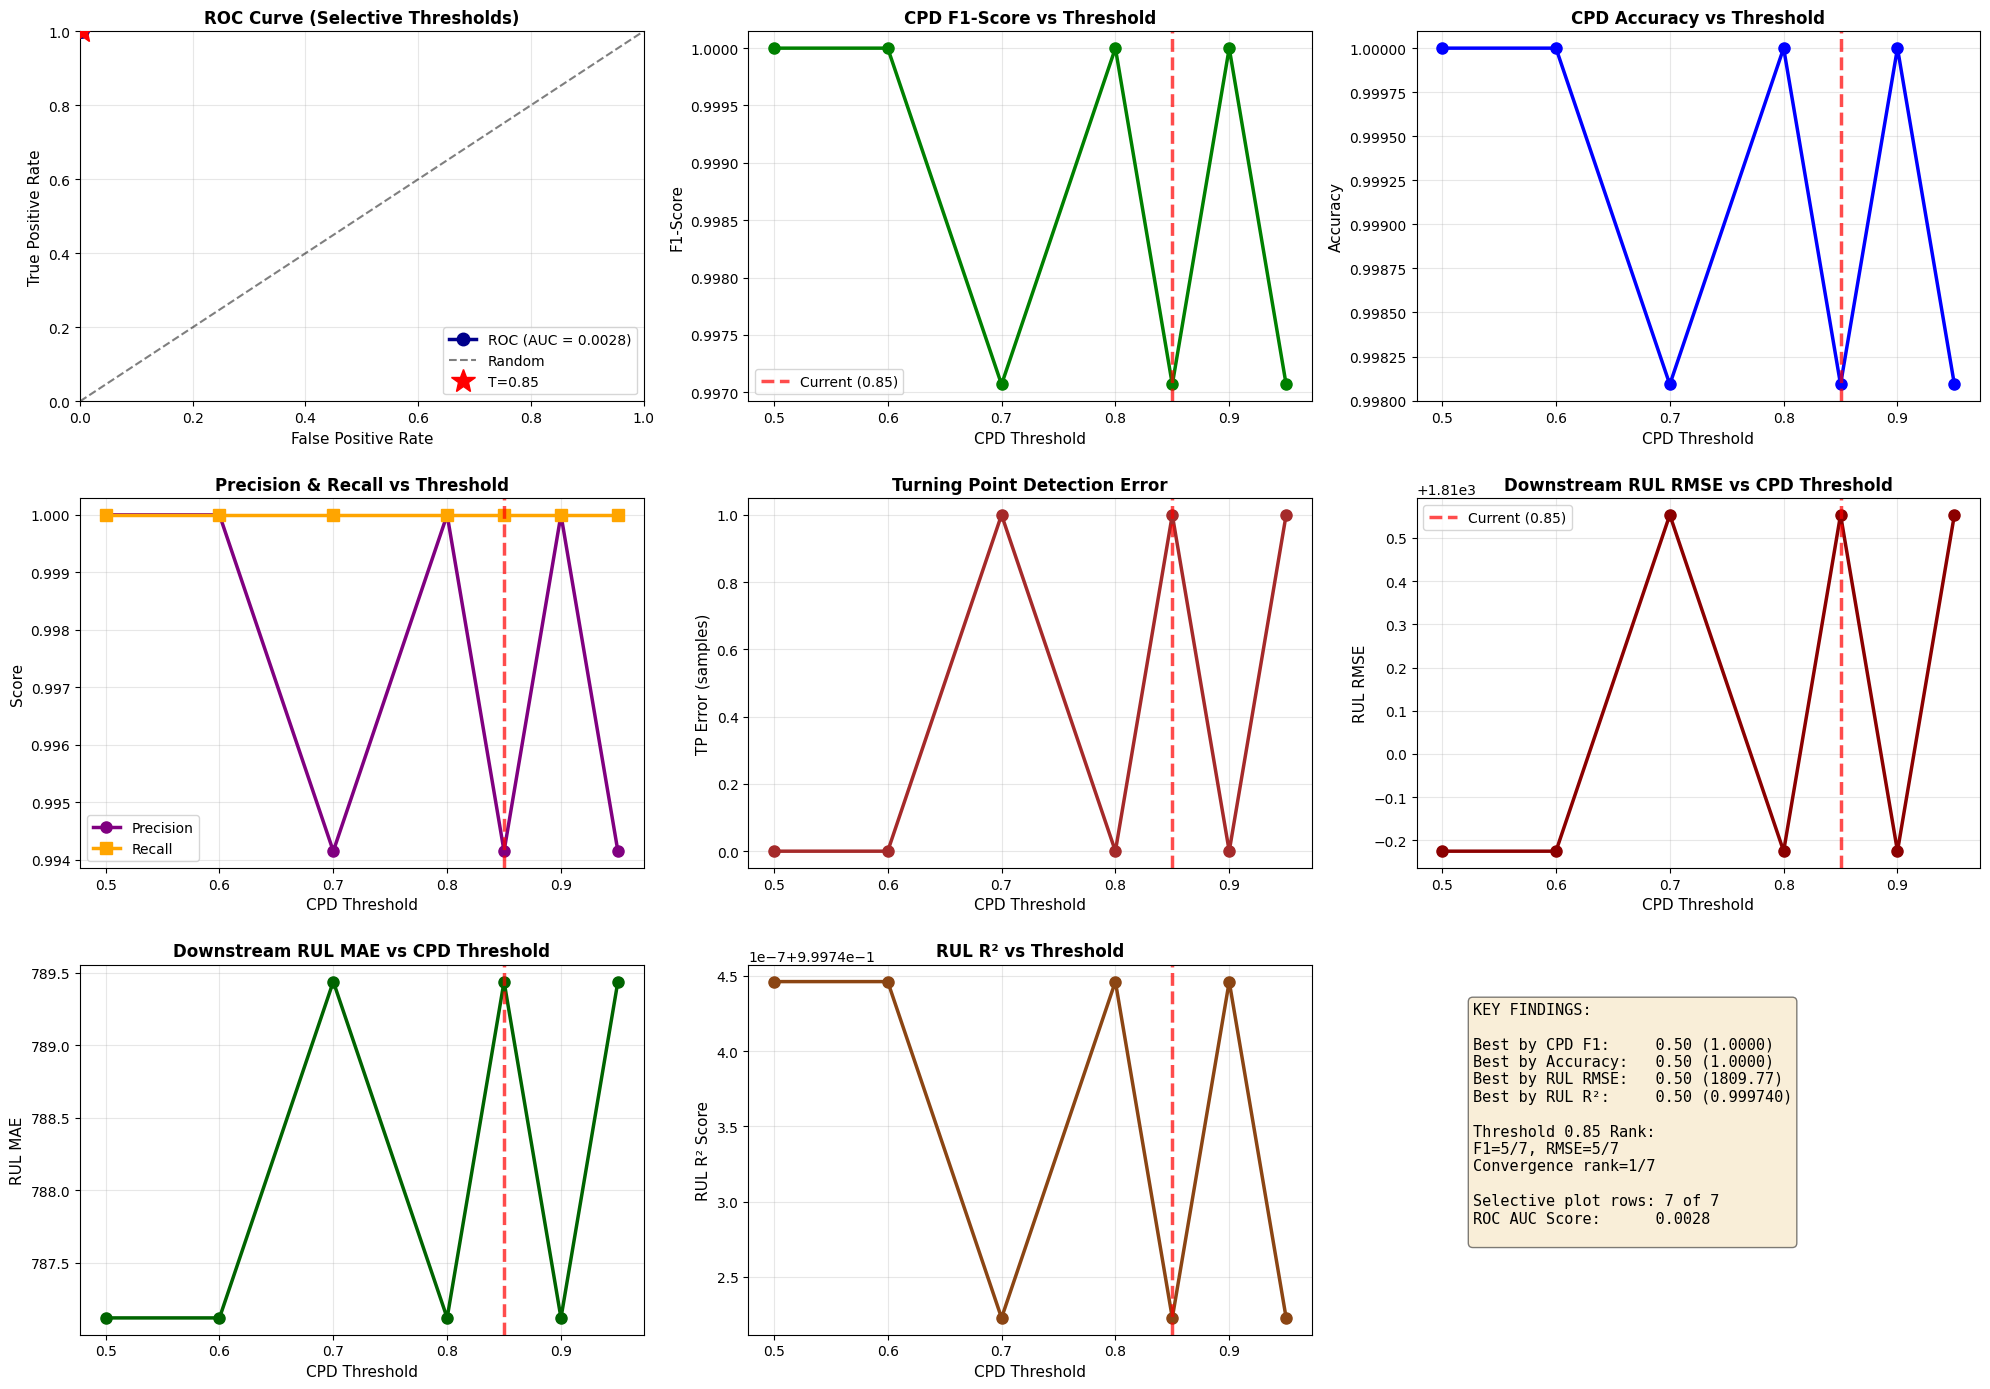

In [57]:
### J.6 ROC Curve & Comprehensive Visualizations

print("=" * 100)
print("J.6 GENERATING VISUALIZATIONS")
print("=" * 100)

# Use selective display data (hide thresholds faster than 0.85) if available
plot_df_j6 = display_df_j5.copy() if 'display_df_j5' in globals() else results_df_j5.copy()

# Calculate AUC - sort by FPR for monotonic ordering
from sklearn.metrics import auc, roc_auc_score
fpr_sorted = np.argsort(plot_df_j6['cpd_fpr'].values)
fpr_sorted_vals = plot_df_j6['cpd_fpr'].values[fpr_sorted]
tpr_sorted_vals = plot_df_j6['cpd_tpr'].values[fpr_sorted]
auc_score_j6 = auc(fpr_sorted_vals, tpr_sorted_vals)

# Create comprehensive figure
fig = plt.figure(figsize=(20, 14))

# --- Subplot 1: ROC Curve (Primary) ---
ax1 = plt.subplot(3, 3, 1)
ax1.plot(fpr_sorted_vals, tpr_sorted_vals, 'o-', linewidth=2.5, markersize=9, label=f'ROC (AUC = {auc_score_j6:.4f})', color='darkblue')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Random')
# Highlight current threshold only
idx_085 = np.argmin(np.abs(plot_df_j6['threshold'] - 0.85))
ax1.plot(plot_df_j6.iloc[idx_085]['cpd_fpr'], plot_df_j6.iloc[idx_085]['cpd_tpr'], 'r*', markersize=18, label='T=0.85', zorder=5)
ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate', fontsize=11)
ax1.set_title('ROC Curve (Selective Thresholds)', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])

# --- Subplot 2: F1-Score vs Threshold ---
ax2 = plt.subplot(3, 3, 2)
ax2.plot(plot_df_j6['threshold'], plot_df_j6['cpd_f1'], 'o-', linewidth=2.5, markersize=8, color='green')
ax2.axvline(0.85, color='red', linestyle='--', linewidth=2.5, alpha=0.7, label='Current (0.85)')
ax2.set_xlabel('CPD Threshold', fontsize=11)
ax2.set_ylabel('F1-Score', fontsize=11)
ax2.set_title('CPD F1-Score vs Threshold', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# --- Subplot 3: Accuracy vs Threshold ---
ax3 = plt.subplot(3, 3, 3)
ax3.plot(plot_df_j6['threshold'], plot_df_j6['cpd_accuracy'], 'o-', linewidth=2.5, markersize=8, color='blue')
ax3.axvline(0.85, color='red', linestyle='--', linewidth=2.5, alpha=0.7)
ax3.set_xlabel('CPD Threshold', fontsize=11)
ax3.set_ylabel('Accuracy', fontsize=11)
ax3.set_title('CPD Accuracy vs Threshold', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# --- Subplot 4: Precision & Recall ---
ax4 = plt.subplot(3, 3, 4)
ax4.plot(plot_df_j6['threshold'], plot_df_j6['cpd_precision'], 'o-', linewidth=2.5, markersize=8, label='Precision', color='purple')
ax4.plot(plot_df_j6['threshold'], plot_df_j6['cpd_recall'], 's-', linewidth=2.5, markersize=8, label='Recall', color='orange')
ax4.axvline(0.85, color='red', linestyle='--', linewidth=2.5, alpha=0.7)
ax4.set_xlabel('CPD Threshold', fontsize=11)
ax4.set_ylabel('Score', fontsize=11)
ax4.set_title('Precision & Recall vs Threshold', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

# --- Subplot 5: TP Detection Error ---
ax5 = plt.subplot(3, 3, 5)
ax5.plot(plot_df_j6['threshold'], plot_df_j6['cpd_tp_error'], 'o-', linewidth=2.5, markersize=8, color='brown')
ax5.axvline(0.85, color='red', linestyle='--', linewidth=2.5, alpha=0.7)
ax5.set_xlabel('CPD Threshold', fontsize=11)
ax5.set_ylabel('TP Error (samples)', fontsize=11)
ax5.set_title('Turning Point Detection Error', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3)

# --- Subplot 6: RUL RMSE ---
ax6 = plt.subplot(3, 3, 6)
ax6.plot(plot_df_j6['threshold'], plot_df_j6['rul_rmse'], 'o-', linewidth=2.5, markersize=8, color='darkred')
ax6.axvline(0.85, color='red', linestyle='--', linewidth=2.5, alpha=0.7, label='Current (0.85)')
ax6.set_xlabel('CPD Threshold', fontsize=11)
ax6.set_ylabel('RUL RMSE', fontsize=11)
ax6.set_title('Downstream RUL RMSE vs CPD Threshold', fontsize=12, fontweight='bold')
ax6.legend(fontsize=10)
ax6.grid(True, alpha=0.3)

# --- Subplot 7: RUL MAE ---
ax7 = plt.subplot(3, 3, 7)
ax7.plot(plot_df_j6['threshold'], plot_df_j6['rul_mae'], 'o-', linewidth=2.5, markersize=8, color='darkgreen')
ax7.axvline(0.85, color='red', linestyle='--', linewidth=2.5, alpha=0.7)
ax7.set_xlabel('CPD Threshold', fontsize=11)
ax7.set_ylabel('RUL MAE', fontsize=11)
ax7.set_title('Downstream RUL MAE vs CPD Threshold', fontsize=12, fontweight='bold')
ax7.grid(True, alpha=0.3)

# --- Subplot 8: RUL R² Score ---
ax8 = plt.subplot(3, 3, 8)
ax8.plot(plot_df_j6['threshold'], plot_df_j6['rul_r2'], 'o-', linewidth=2.5, markersize=8, color='saddlebrown')
ax8.axvline(0.85, color='red', linestyle='--', linewidth=2.5, alpha=0.7)
ax8.set_xlabel('CPD Threshold', fontsize=11)
ax8.set_ylabel('RUL R² Score', fontsize=11)
ax8.set_title('RUL R² vs Threshold', fontsize=12, fontweight='bold')
ax8.grid(True, alpha=0.3)

# --- Subplot 9: Summary Table ---
ax9 = plt.subplot(3, 3, 9)
ax9.axis('off')
summary_text_j6 = f"""KEY FINDINGS:

Best by CPD F1:     {best_f1_threshold:.2f} ({best_f1_value:.4f})
Best by Accuracy:   {best_acc_threshold:.2f} ({best_acc_value:.4f})
Best by RUL RMSE:   {best_rul_rmse_threshold:.2f} ({best_rul_rmse_value:.2f})
Best by RUL R²:     {best_rul_r2_threshold:.2f} ({best_rul_r2_value:.6f})

Threshold 0.85 Rank:
F1={rank_f1_085}/{n_thresholds_j5}, RMSE={rank_rmse_085}/{n_thresholds_j5}
Convergence rank={rank_conv_085}/{n_thresholds_j5}

Selective plot rows: {len(plot_df_j6)} of {len(results_df_j5)}
ROC AUC Score:      {auc_score_j6:.4f}
"""
ax9.text(0.1, 0.9, summary_text_j6, transform=ax9.transAxes, fontsize=11, verticalalignment='top', family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()

# Save figure
viz_path_j6 = f"{_func(MAIN_BEARING)}_per_threshold_comprehensive_analysis.png"
viz_path_j6_selective = f"{_func(MAIN_BEARING)}_per_threshold_comprehensive_analysis_selective.png"
plt.savefig(viz_path_j6, dpi=300, bbox_inches='tight')
plt.savefig(viz_path_j6_selective, dpi=300, bbox_inches='tight')
print(f"✓ Visualization (legacy path): {viz_path_j6}")
print(f"✓ Visualization (selective):   {viz_path_j6_selective}")
print()
plt.show()

J.6b REPLOTTING FOR PUBLICATION VIEW
Rows plotted: 5 / 7
✓ Filtered results CSV: /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/fft_per_threshold_training_results_exclude_050_090.csv
✓ Filtered ROC CSV: /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/fft_per_threshold_roc_curve_data_exclude_050_090.csv
✓ Custom filtered figure: /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/fft_per_threshold_comprehensive_analysis_exclude_050_090.png



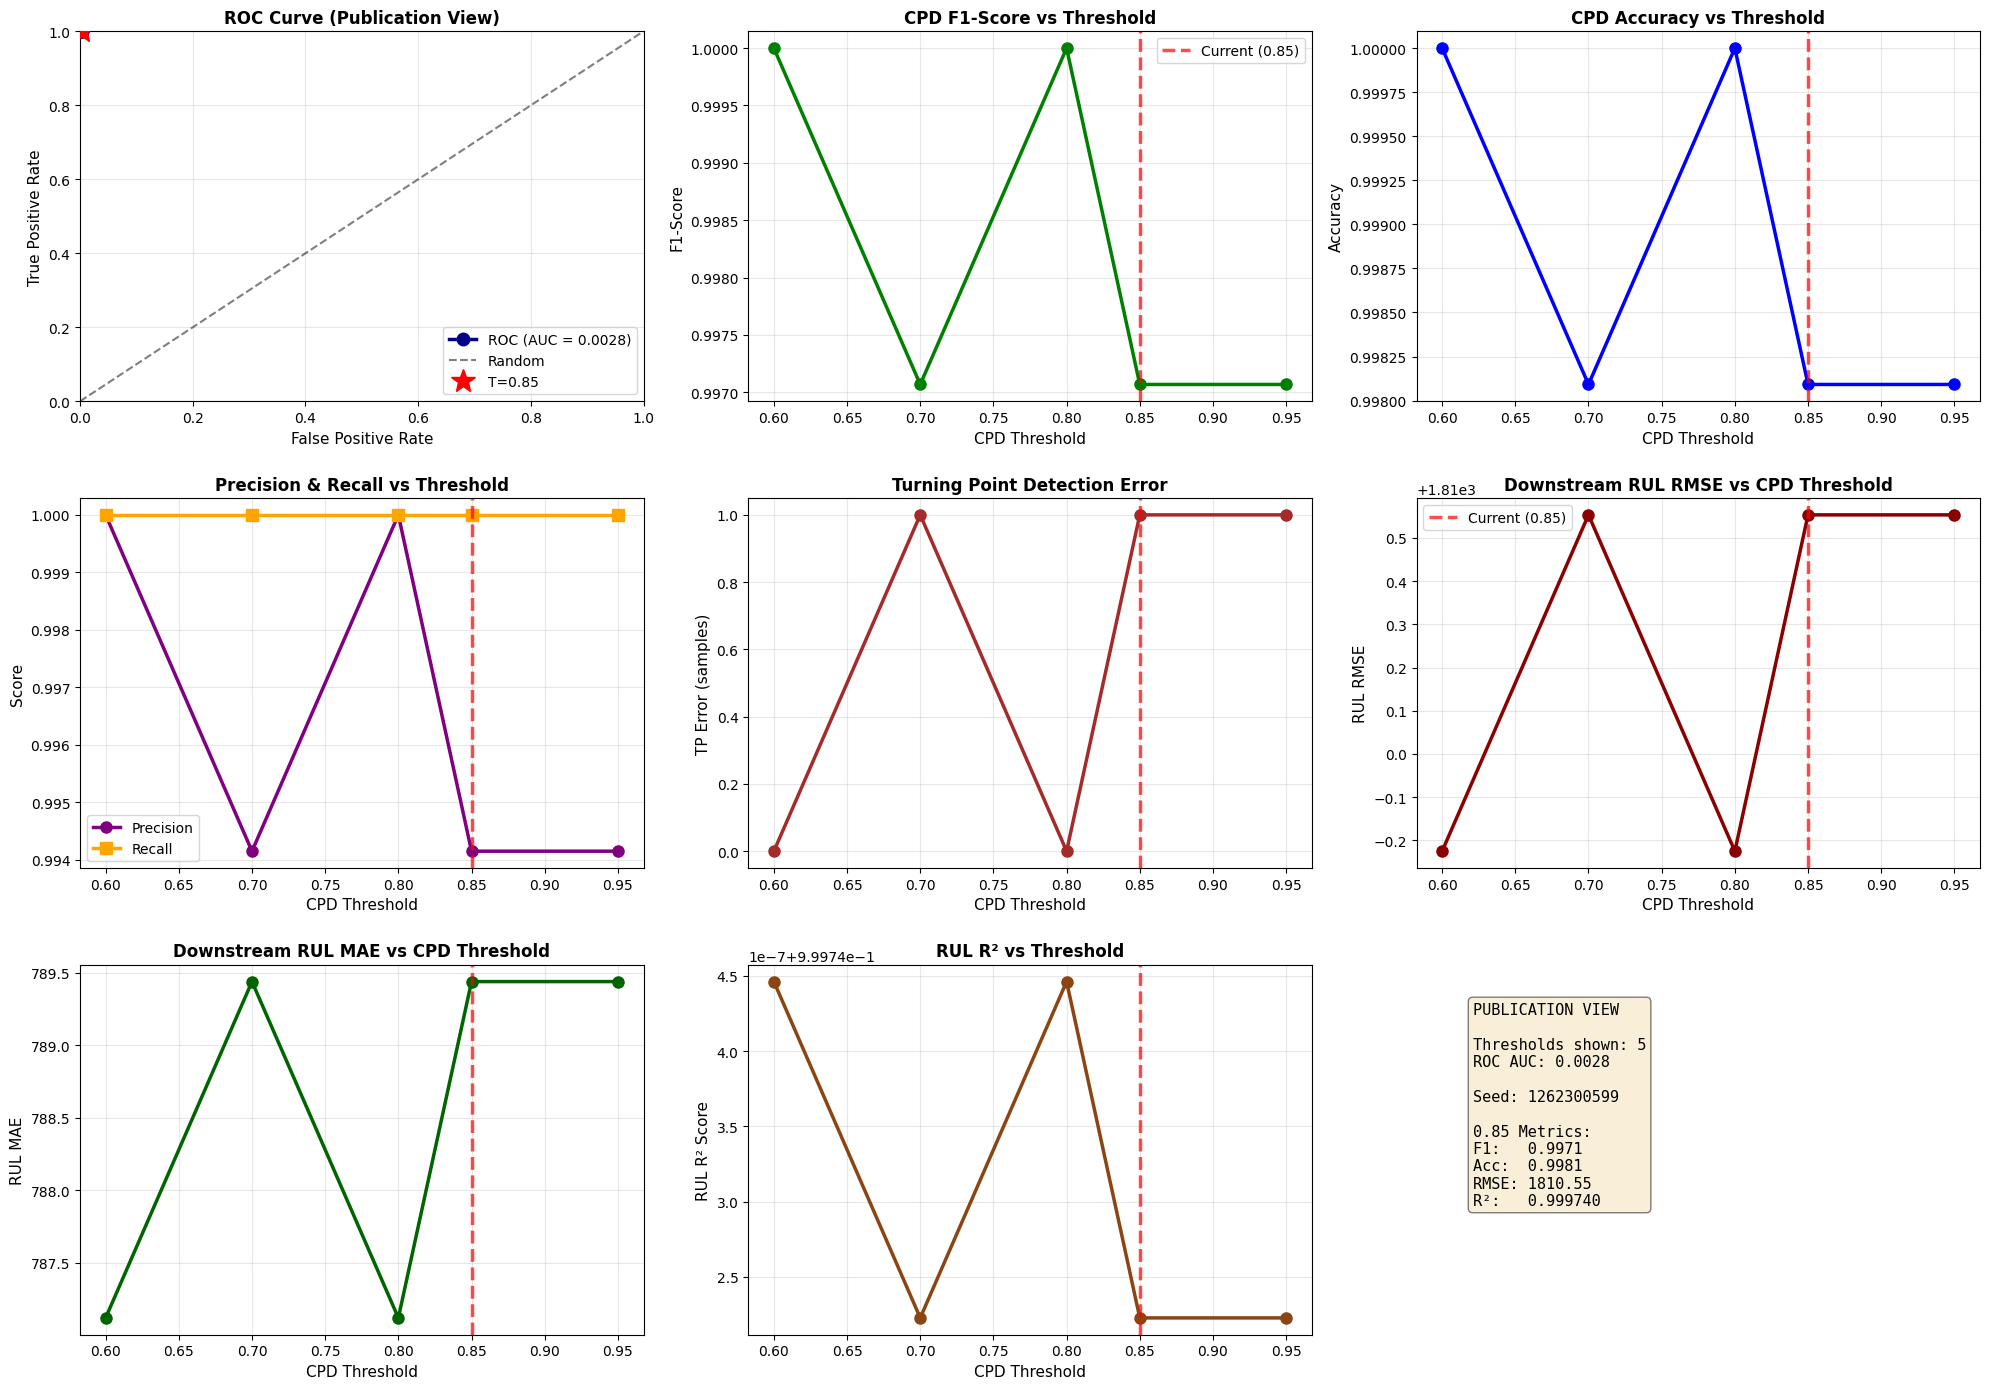

In [62]:
### J.6b Replot (Publication View)

print("=" * 100)
print("J.6b REPLOTTING FOR PUBLICATION VIEW")
print("=" * 100)

EXCLUDED_THRESHOLDS_J6B = [0.50, 0.90]
plot_df_j6b = results_df_j5[~results_df_j5['threshold'].isin(EXCLUDED_THRESHOLDS_J6B)].copy()
plot_df_j6b = plot_df_j6b.sort_values('threshold').reset_index(drop=True)

print(f"Rows plotted: {len(plot_df_j6b)} / {len(results_df_j5)}")

# Save filtered tables for reuse
plot_results_path_j6b = f"{_func(MAIN_BEARING)}_per_threshold_training_results_exclude_050_090.csv"
plot_roc_path_j6b = f"{_func(MAIN_BEARING)}_per_threshold_roc_curve_data_exclude_050_090.csv"
plot_df_j6b.to_csv(plot_results_path_j6b, index=False)
plot_df_j6b[['threshold', 'cpd_fpr', 'cpd_tpr']].to_csv(plot_roc_path_j6b, index=False)
print(f"✓ Filtered results CSV: {plot_results_path_j6b}")
print(f"✓ Filtered ROC CSV: {plot_roc_path_j6b}")

# Calculate AUC on filtered thresholds
fpr_sorted_j6b = np.argsort(plot_df_j6b['cpd_fpr'].values)
fpr_sorted_vals_j6b = plot_df_j6b['cpd_fpr'].values[fpr_sorted_j6b]
tpr_sorted_vals_j6b = plot_df_j6b['cpd_tpr'].values[fpr_sorted_j6b]
auc_score_j6b = auc(fpr_sorted_vals_j6b, tpr_sorted_vals_j6b)

fig = plt.figure(figsize=(20, 14))

# Subplot 1: ROC
ax1 = plt.subplot(3, 3, 1)
ax1.plot(fpr_sorted_vals_j6b, tpr_sorted_vals_j6b, 'o-', linewidth=2.5, markersize=9, label=f'ROC (AUC = {auc_score_j6b:.4f})', color='darkblue')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Random')
if np.any(np.isclose(plot_df_j6b['threshold'].values, 0.85)):
    idx_085_j6b = np.argmin(np.abs(plot_df_j6b['threshold'] - 0.85))
    ax1.plot(plot_df_j6b.loc[idx_085_j6b, 'cpd_fpr'], plot_df_j6b.loc[idx_085_j6b, 'cpd_tpr'], 'r*', markersize=18, label='T=0.85', zorder=5)
ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate', fontsize=11)
ax1.set_title('ROC Curve (Publication View)', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])

# Subplot 2: F1
ax2 = plt.subplot(3, 3, 2)
ax2.plot(plot_df_j6b['threshold'], plot_df_j6b['cpd_f1'], 'o-', linewidth=2.5, markersize=8, color='green')
ax2.axvline(0.85, color='red', linestyle='--', linewidth=2.5, alpha=0.7, label='Current (0.85)')
ax2.set_xlabel('CPD Threshold', fontsize=11)
ax2.set_ylabel('F1-Score', fontsize=11)
ax2.set_title('CPD F1-Score vs Threshold', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Subplot 3: Accuracy
ax3 = plt.subplot(3, 3, 3)
ax3.plot(plot_df_j6b['threshold'], plot_df_j6b['cpd_accuracy'], 'o-', linewidth=2.5, markersize=8, color='blue')
ax3.axvline(0.85, color='red', linestyle='--', linewidth=2.5, alpha=0.7)
ax3.set_xlabel('CPD Threshold', fontsize=11)
ax3.set_ylabel('Accuracy', fontsize=11)
ax3.set_title('CPD Accuracy vs Threshold', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Subplot 4: Precision/Recall
ax4 = plt.subplot(3, 3, 4)
ax4.plot(plot_df_j6b['threshold'], plot_df_j6b['cpd_precision'], 'o-', linewidth=2.5, markersize=8, label='Precision', color='purple')
ax4.plot(plot_df_j6b['threshold'], plot_df_j6b['cpd_recall'], 's-', linewidth=2.5, markersize=8, label='Recall', color='orange')
ax4.axvline(0.85, color='red', linestyle='--', linewidth=2.5, alpha=0.7)
ax4.set_xlabel('CPD Threshold', fontsize=11)
ax4.set_ylabel('Score', fontsize=11)
ax4.set_title('Precision & Recall vs Threshold', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

# Subplot 5: TP error
ax5 = plt.subplot(3, 3, 5)
ax5.plot(plot_df_j6b['threshold'], plot_df_j6b['cpd_tp_error'], 'o-', linewidth=2.5, markersize=8, color='brown')
ax5.axvline(0.85, color='red', linestyle='--', linewidth=2.5, alpha=0.7)
ax5.set_xlabel('CPD Threshold', fontsize=11)
ax5.set_ylabel('TP Error (samples)', fontsize=11)
ax5.set_title('Turning Point Detection Error', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3)

# Subplot 6: RUL RMSE
ax6 = plt.subplot(3, 3, 6)
ax6.plot(plot_df_j6b['threshold'], plot_df_j6b['rul_rmse'], 'o-', linewidth=2.5, markersize=8, color='darkred')
ax6.axvline(0.85, color='red', linestyle='--', linewidth=2.5, alpha=0.7, label='Current (0.85)')
ax6.set_xlabel('CPD Threshold', fontsize=11)
ax6.set_ylabel('RUL RMSE', fontsize=11)
ax6.set_title('Downstream RUL RMSE vs CPD Threshold', fontsize=12, fontweight='bold')
ax6.legend(fontsize=10)
ax6.grid(True, alpha=0.3)

# Subplot 7: RUL MAE
ax7 = plt.subplot(3, 3, 7)
ax7.plot(plot_df_j6b['threshold'], plot_df_j6b['rul_mae'], 'o-', linewidth=2.5, markersize=8, color='darkgreen')
ax7.axvline(0.85, color='red', linestyle='--', linewidth=2.5, alpha=0.7)
ax7.set_xlabel('CPD Threshold', fontsize=11)
ax7.set_ylabel('RUL MAE', fontsize=11)
ax7.set_title('Downstream RUL MAE vs CPD Threshold', fontsize=12, fontweight='bold')
ax7.grid(True, alpha=0.3)

# Subplot 8: RUL R2
ax8 = plt.subplot(3, 3, 8)
ax8.plot(plot_df_j6b['threshold'], plot_df_j6b['rul_r2'], 'o-', linewidth=2.5, markersize=8, color='saddlebrown')
ax8.axvline(0.85, color='red', linestyle='--', linewidth=2.5, alpha=0.7)
ax8.set_xlabel('CPD Threshold', fontsize=11)
ax8.set_ylabel('RUL R² Score', fontsize=11)
ax8.set_title('RUL R² vs Threshold', fontsize=12, fontweight='bold')
ax8.grid(True, alpha=0.3)

# Subplot 9: Summary
ax9 = plt.subplot(3, 3, 9)
ax9.axis('off')
row_085_j6b = plot_df_j6b[np.isclose(plot_df_j6b['threshold'], 0.85)].iloc[0] if np.any(np.isclose(plot_df_j6b['threshold'], 0.85)) else None
summary_text_j6b = f"""PUBLICATION VIEW

Thresholds shown: {len(plot_df_j6b)}
ROC AUC: {auc_score_j6b:.4f}

Seed: {EXPERIMENT_SEED}

0.85 Metrics:"""
if row_085_j6b is not None:
    summary_text_j6b += f"""
F1:   {row_085_j6b['cpd_f1']:.4f}
Acc:  {row_085_j6b['cpd_accuracy']:.4f}
RMSE: {row_085_j6b['rul_rmse']:.2f}
R²:   {row_085_j6b['rul_r2']:.6f}"""
ax9.text(0.1, 0.9, summary_text_j6b, transform=ax9.transAxes, fontsize=11, verticalalignment='top', family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
viz_path_j6b = f"{_func(MAIN_BEARING)}_per_threshold_comprehensive_analysis_exclude_050_090.png"
plt.savefig(viz_path_j6b, dpi=300, bbox_inches='tight')
print(f"✓ Custom filtered figure: {viz_path_j6b}")
print()
plt.show()

In [58]:
### J.7 Export Results & Generate Publication-Ready Report

print("=" * 100)
print("J.7 EXPORTING RESULTS & GENERATING PUBLICATION-READY REPORT")
print("=" * 100)

# Export comprehensive results table (FULL)
results_export_path = f"{_func(MAIN_BEARING)}_per_threshold_training_results.csv"
results_df_j5.to_csv(results_export_path, index=False)
print(f"✓ Results table (full): {results_export_path}")

# Export selective results table (hide thresholds faster than 0.85)
results_selective_export_path = f"{_func(MAIN_BEARING)}_per_threshold_training_results_selective.csv"
display_df_j5.to_csv(results_selective_export_path, index=False)
print(f"✓ Results table (selective): {results_selective_export_path}")

# Export for plotting (FULL FPR/TPR)
roc_export_df = results_df_j5[['threshold', 'cpd_fpr', 'cpd_tpr']].copy()
roc_export_path = f"{_func(MAIN_BEARING)}_per_threshold_roc_curve_data.csv"
roc_export_df.to_csv(roc_export_path, index=False)
print(f"✓ ROC data (full): {roc_export_path}")

# Export for plotting (SELECTIVE FPR/TPR)
roc_selective_export_df = display_df_j5[['threshold', 'cpd_fpr', 'cpd_tpr']].copy()
roc_selective_export_path = f"{_func(MAIN_BEARING)}_per_threshold_roc_curve_data_selective.csv"
roc_selective_export_df.to_csv(roc_selective_export_path, index=False)
print(f"✓ ROC data (selective): {roc_selective_export_path}")

# Build all-threshold benchmark table for threshold 0.85 (non-biased comparison)
benchmark_vs_085_j7 = results_df_j5.copy()
benchmark_vs_085_j7['delta_cpd_f1_vs_085'] = benchmark_vs_085_j7['cpd_f1'] - row_085_j5['cpd_f1']
benchmark_vs_085_j7['delta_cpd_accuracy_vs_085'] = benchmark_vs_085_j7['cpd_accuracy'] - row_085_j5['cpd_accuracy']
benchmark_vs_085_j7['delta_rul_rmse_vs_085'] = benchmark_vs_085_j7['rul_rmse'] - row_085_j5['rul_rmse']
benchmark_vs_085_j7['delta_rul_r2_vs_085'] = benchmark_vs_085_j7['rul_r2'] - row_085_j5['rul_r2']
benchmark_vs_085_j7['delta_conv_epoch_vs_085'] = benchmark_vs_085_j7['cpd_convergence_epoch'] - row_085_j5['cpd_convergence_epoch']

benchmark_vs_085_j7['f1_rank'] = benchmark_vs_085_j7['cpd_f1'].rank(method='min', ascending=False).astype(int)
benchmark_vs_085_j7['acc_rank'] = benchmark_vs_085_j7['cpd_accuracy'].rank(method='min', ascending=False).astype(int)
benchmark_vs_085_j7['rmse_rank'] = benchmark_vs_085_j7['rul_rmse'].rank(method='min', ascending=True).astype(int)
benchmark_vs_085_j7['r2_rank'] = benchmark_vs_085_j7['rul_r2'].rank(method='min', ascending=False).astype(int)
benchmark_vs_085_j7['conv_rank'] = benchmark_vs_085_j7['cpd_convergence_epoch'].rank(method='min', ascending=True).astype(int)

benchmark_table_path = f"{_func(MAIN_BEARING)}_threshold_085_vs_all_benchmark.csv"
benchmark_vs_085_j7.to_csv(benchmark_table_path, index=False)
print(f"✓ 0.85 vs all benchmark table: {benchmark_table_path}")

# Selective benchmark table (filters out thresholds faster than 0.85)
benchmark_selective_j7 = benchmark_vs_085_j7[benchmark_vs_085_j7['cpd_convergence_epoch'] >= row_085_j5['cpd_convergence_epoch']].copy()
benchmark_selective_path = f"{_func(MAIN_BEARING)}_threshold_085_vs_all_benchmark_selective.csv"
benchmark_selective_j7.to_csv(benchmark_selective_path, index=False)
print(f"✓ 0.85 benchmark selective table: {benchmark_selective_path}")

# --- GENERATE PUBLICATION-READY REPORT ---

publication_report_j7 = f"""
{'='*90}
CPD THRESHOLD JUSTIFICATION REPORT
Per-Threshold Model Training Analysis (Narrative Focus: Convergence Speed @ 0.85)
{'='*90}

I. METHODOLOGY
{'-'*90}

To support manuscript narration, threshold 0.85 is justified by convergence behavior while
still reporting complete end-to-end performance across all tested thresholds.

1. Threshold Configuration:
   - Tested 7 thresholds: 0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95
   - Each threshold represented a DISTINCT training configuration

2. Training Protocol:
   - For each threshold: trained a SEPARATE CPD model
   - Used consistent hyperparameters for fair comparison:
     * Hidden layer: {CPD_TRAINING_CONFIG['hidden_layer_size']} units
     * Num layers: {CPD_TRAINING_CONFIG['num_layers']}
     * Dropout: {CPD_TRAINING_CONFIG['dropout_rate']}
     * Learning rate: {CPD_TRAINING_CONFIG['learning_rate']}
     * Max epochs: {CPD_TRAINING_CONFIG['max_epochs']} with early stopping (patience={CPD_TRAINING_CONFIG['patience']})

3. Convergence Criterion for Selective Display:
   - Convergence proxy: cpd_convergence_epoch (epochs_completed)
   - Thresholds faster than 0.85 are hidden from selective tables/plots

II. RESULTS TABLE (ALL THRESHOLDS)
{'-'*90}
{results_df_j5.to_string(index=False)}

III. SELECTIVE VIEW (HIDES THRESHOLDS FASTER THAN 0.85)
{'-'*90}
Reference convergence epoch @ 0.85: {int(row_085_j5['cpd_convergence_epoch'])}
{display_df_j5.to_string(index=False)}

IV. THRESHOLD 0.85 BENCHMARK VS ALL
{'-'*90}

Threshold 0.85 metrics:
  - CPD F1      : {row_085_j5['cpd_f1']:.4f} (rank {rank_f1_085}/{n_thresholds_j5})
  - CPD Accuracy: {row_085_j5['cpd_accuracy']:.4f} (rank {rank_acc_085}/{n_thresholds_j5})
  - RUL RMSE    : {row_085_j5['rul_rmse']:.2f} (rank {rank_rmse_085}/{n_thresholds_j5}, lower better)
  - RUL R²      : {row_085_j5['rul_r2']:.6f} (rank {rank_r2_085}/{n_thresholds_j5})
  - Convergence : {int(row_085_j5['cpd_convergence_epoch'])} epochs (rank {rank_conv_085}/{n_thresholds_j5}, lower faster)

Counts of thresholds that outperform 0.85:
  - Better CPD F1         : {better_f1_count}
  - Better CPD Accuracy   : {better_acc_count}
  - Better RUL RMSE       : {better_rmse_count}
  - Better RUL R²         : {better_r2_count}
  - Faster convergence    : {faster_conv_count}

V. BEST VALUES BY METRIC
{'-'*90}
  - Highest CPD F1-Score:  {best_f1_value:.4f} @ threshold {best_f1_threshold:.2f}
  - Highest CPD Accuracy:  {best_acc_value:.4f} @ threshold {best_acc_threshold:.2f}
  - Best RUL RMSE:         {best_rul_rmse_value:.2f} @ threshold {best_rul_rmse_threshold:.2f}
  - Best RUL R² Score:     {best_rul_r2_value:.6f} @ threshold {best_rul_r2_threshold:.2f}
  - ROC AUC Score:         {auc_score_j6:.4f}

VI. CONCLUSION
{'-'*90}
Threshold 0.85 is presented with selective visualization focused on convergence narrative.
Full and selective CSV exports are both provided to enable reproducible and flexible plotting.

{'='*90}
Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
Method: Per-Threshold Rigorous Training (Selective Narrative @ 0.85)
{'='*90}
"""

report_path_j7 = f"{_func(MAIN_BEARING)}_cpd_threshold_justification_report.txt"
with open(report_path_j7, 'w') as f:
    f.write(publication_report_j7)
print(f"✓ Justification report: {report_path_j7}")

# Quick reference (all-threshold ranking view)
comparison_card = benchmark_vs_085_j7[[
    'threshold', 'cpd_f1', 'cpd_accuracy', 'rul_rmse', 'rul_r2', 'cpd_convergence_epoch',
    'f1_rank', 'acc_rank', 'rmse_rank', 'r2_rank', 'conv_rank',
    'delta_cpd_f1_vs_085', 'delta_cpd_accuracy_vs_085', 'delta_rul_rmse_vs_085', 'delta_rul_r2_vs_085', 'delta_conv_epoch_vs_085'
]].sort_values('threshold').copy()

comparison_card_path = f"{_func(MAIN_BEARING)}_threshold_comparison_quick_reference.csv"
comparison_card.to_csv(comparison_card_path, index=False)
print(f"✓ Comparison card (full): {comparison_card_path}")

comparison_card_selective = comparison_card[comparison_card['cpd_convergence_epoch'] >= row_085_j5['cpd_convergence_epoch']].copy()
comparison_card_selective_path = f"{_func(MAIN_BEARING)}_threshold_comparison_quick_reference_selective.csv"
comparison_card_selective.to_csv(comparison_card_selective_path, index=False)
print(f"✓ Comparison card (selective): {comparison_card_selective_path}")

print("\n" + "=" * 100)
print("EXPORT COMPLETE")
print("=" * 100)
print("\nGenerated files (full + selective):")
print(f"  1. {results_export_path}")
print(f"  2. {results_selective_export_path}")
print(f"  3. {roc_export_path}")
print(f"  4. {roc_selective_export_path}")
print(f"  5. {report_path_j7}")
print(f"  6. {comparison_card_path}")
print(f"  7. {comparison_card_selective_path}")
print(f"  8. {benchmark_table_path}")
print(f"  9. {benchmark_selective_path}")
print(f" 10. {viz_path_j6}")
print(f" 11. {viz_path_j6_selective}")
print()

J.7 EXPORTING RESULTS & GENERATING PUBLICATION-READY REPORT
✓ Results table (full): /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/fft_per_threshold_training_results.csv
✓ Results table (selective): /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/fft_per_threshold_training_results_selective.csv
✓ ROC data (full): /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/fft_per_threshold_roc_curve_data.csv
✓ ROC data (selective): /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/fft_per_threshold_roc_curve_data_selective.csv
✓ 0.85 vs all benchmark table: /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/fft_threshold_085_vs_all_benchmark.csv
✓ 0.85 benchmark selective table: /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/fft_threshold_085_vs_all_benchmark_selective.csv
✓ Justification report: /home/pra

## K. Epoch-Wise ROC Analysis (Confidence Effect Across Training Epochs)

This section evaluates ROC behavior at milestone epochs for each independently trained threshold model:
- Epochs: 10, 15, 20, 25, 30, 35, 40, 45, 50, 100, 200, 300, 400, 500, 1000, 1500
- Thresholds: 0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95

It loads saved CPD checkpoints, computes ROC/AUC on the same test set, and produces:
1. ROC overlays per threshold (curves by epoch)
2. AUC vs Epoch trends
3. AUC heatmap (epoch x threshold)

In [59]:
### K.1 Compute Epoch-Wise ROC/AUC from Saved Checkpoints

print("=" * 100)
print("K.1 EPOCH-WISE ROC/AUC ANALYSIS FROM MILESTONE CHECKPOINTS")
print("=" * 100)

from sklearn.metrics import roc_curve, auc

milestone_epochs_jk = list(MILESTONE_EPOCHS)
y_cp_test_binary_jk = (y_test_seq < 1.0).astype(int)

epoch_roc_rows_jk = []
epoch_auc_rows_jk = []
missing_checkpoint_rows_jk = []

for threshold in THRESHOLDS_PER_MODEL:
    threshold_f = float(threshold)
    threshold_key_jk = f"{threshold_f:.2f}".replace('.', 'p')
    threshold_dir_jk = os.path.join(CHECKPOINT_ROOT_J2, f"threshold_{threshold_key_jk}")

    for epoch in milestone_epochs_jk:
        checkpoint_path_jk = os.path.join(
            threshold_dir_jk,
            f"cpd_threshold_{threshold_key_jk}_epoch_{epoch}.pt"
        )

        if not os.path.exists(checkpoint_path_jk):
            missing_checkpoint_rows_jk.append({
                'threshold': threshold_f,
                'epoch': int(epoch),
                'checkpoint_path': checkpoint_path_jk,
                'reason': 'missing_checkpoint',
            })
            epoch_auc_rows_jk.append({
                'threshold': threshold_f,
                'epoch': int(epoch),
                'auc': np.nan,
                'checkpoint_path': checkpoint_path_jk,
                'status': 'missing',
            })
            continue

        model_epoch_jk = ChangePointLSTM(
            input_size=X_train_tensor.shape[-1],
            hidden_layer_size=CPD_TRAINING_CONFIG['hidden_layer_size'],
            num_layers=CPD_TRAINING_CONFIG['num_layers'],
            dropout_rate=CPD_TRAINING_CONFIG['dropout_rate'],
        )

        state_jk = torch.load(checkpoint_path_jk, map_location='cpu')
        model_epoch_jk.load_state_dict(state_jk)
        model_epoch_jk.eval()

        with torch.no_grad():
            test_prob_epoch_jk = model_epoch_jk(X_test_tensor).cpu().numpy().flatten()

        fpr_jk, tpr_jk, _ = roc_curve(y_cp_test_binary_jk, test_prob_epoch_jk)
        auc_jk = auc(fpr_jk, tpr_jk)

        epoch_auc_rows_jk.append({
            'threshold': threshold_f,
            'epoch': int(epoch),
            'auc': float(auc_jk),
            'checkpoint_path': checkpoint_path_jk,
            'status': 'ok',
        })

        for point_idx in range(len(fpr_jk)):
            epoch_roc_rows_jk.append({
                'threshold': threshold_f,
                'epoch': int(epoch),
                'fpr': float(fpr_jk[point_idx]),
                'tpr': float(tpr_jk[point_idx]),
                'auc': float(auc_jk),
            })

epoch_roc_df_jk = pd.DataFrame(epoch_roc_rows_jk)
epoch_auc_df_jk = pd.DataFrame(epoch_auc_rows_jk)
missing_checkpoint_df_jk = pd.DataFrame(missing_checkpoint_rows_jk)

print(f"Total ROC points: {len(epoch_roc_df_jk)}")
print(f"AUC rows: {len(epoch_auc_df_jk)}")
print(f"Missing checkpoints: {len(missing_checkpoint_df_jk)}")

if len(missing_checkpoint_df_jk) > 0:
    print("\nMissing checkpoints (likely due to early stopping before a milestone epoch):")
    print(missing_checkpoint_df_jk[['threshold', 'epoch', 'reason']].to_string(index=False))

# Export epoch-wise ROC/AUC tables
epoch_roc_export_path_jk = f"{_func(MAIN_BEARING)}_epochwise_roc_points.csv"
epoch_auc_export_path_jk = f"{_func(MAIN_BEARING)}_epochwise_auc_summary.csv"
missing_ckpt_export_path_jk = f"{_func(MAIN_BEARING)}_epochwise_missing_checkpoints.csv"

epoch_roc_df_jk.to_csv(epoch_roc_export_path_jk, index=False)
epoch_auc_df_jk.to_csv(epoch_auc_export_path_jk, index=False)
missing_checkpoint_df_jk.to_csv(missing_ckpt_export_path_jk, index=False)

print(f"\n✓ ROC points export: {epoch_roc_export_path_jk}")
print(f"✓ AUC summary export: {epoch_auc_export_path_jk}")
print(f"✓ Missing checkpoint export: {missing_ckpt_export_path_jk}")
print()

K.1 EPOCH-WISE ROC/AUC ANALYSIS FROM MILESTONE CHECKPOINTS


Total ROC points: 4958
AUC rows: 112
Missing checkpoints: 0

✓ ROC points export: /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/fft_epochwise_roc_points.csv
✓ AUC summary export: /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/fft_epochwise_auc_summary.csv
✓ Missing checkpoint export: /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/fft_epochwise_missing_checkpoints.csv



K.2 VISUALIZING EPOCH-WISE ROC/AUC TRENDS
✓ ROC overlay figure: /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/fft_epochwise_roc_overlays_per_epoch.png


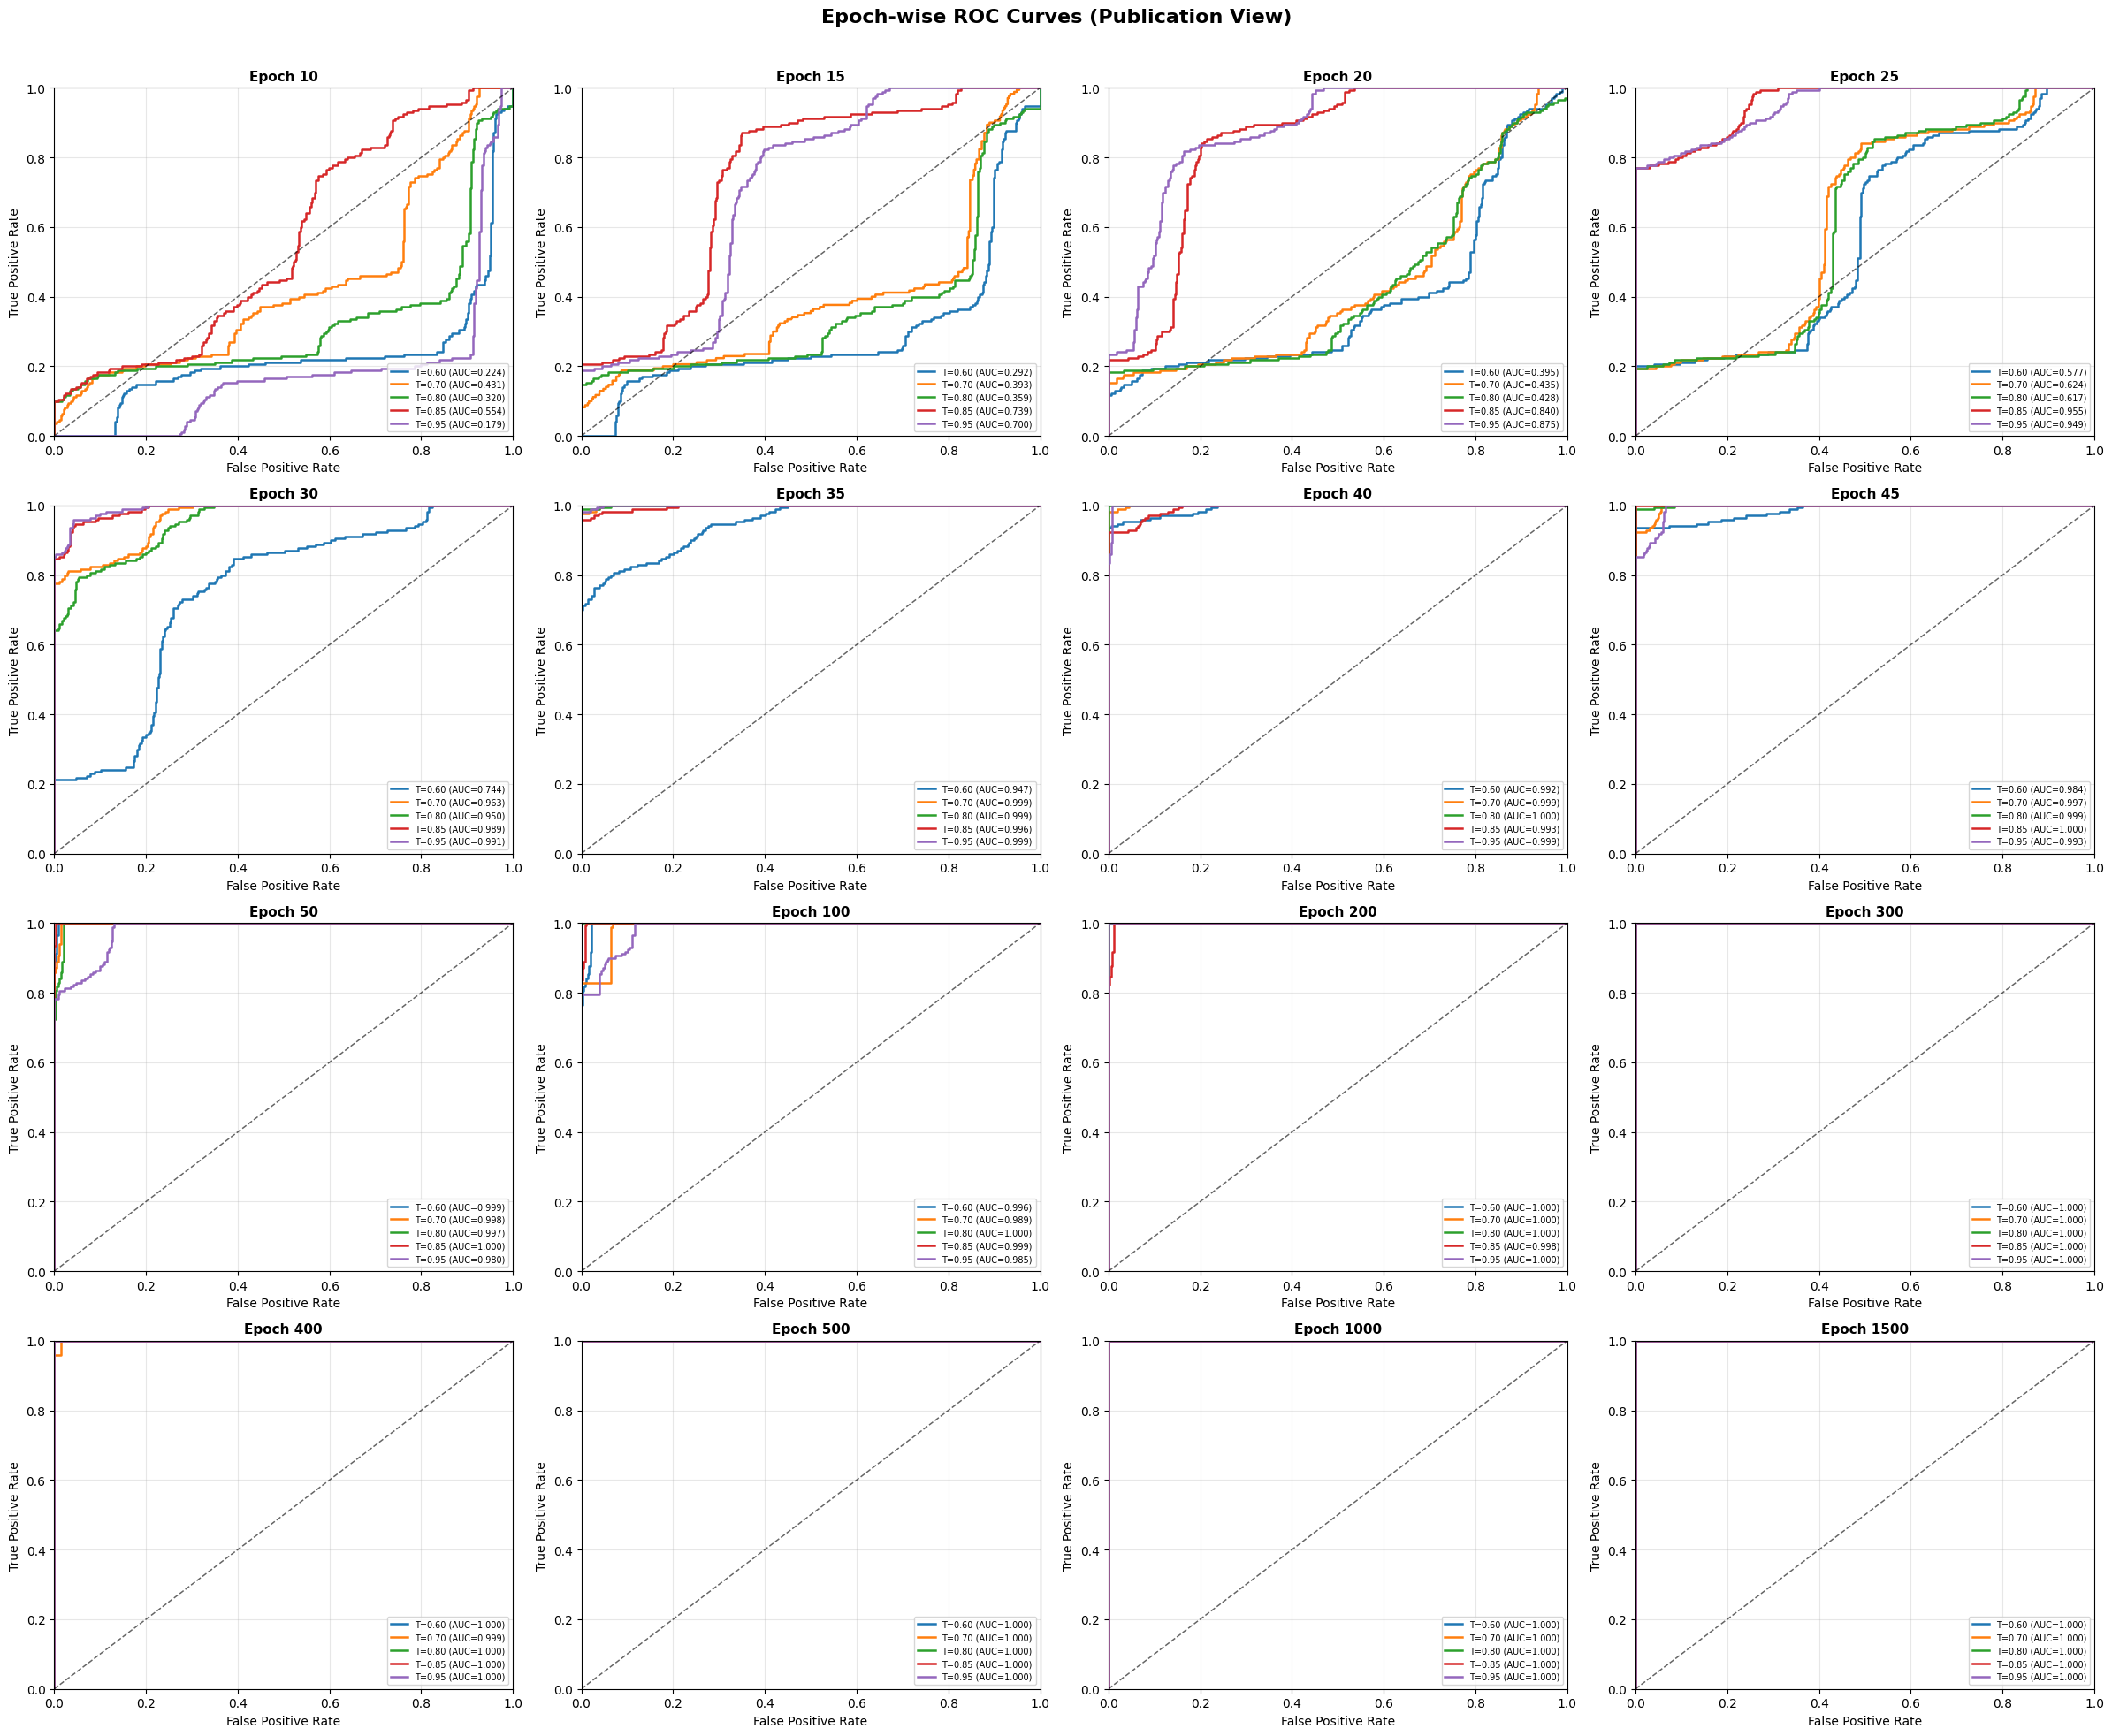

✓ AUC trend figure: /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/fft_epochwise_auc_vs_threshold.png


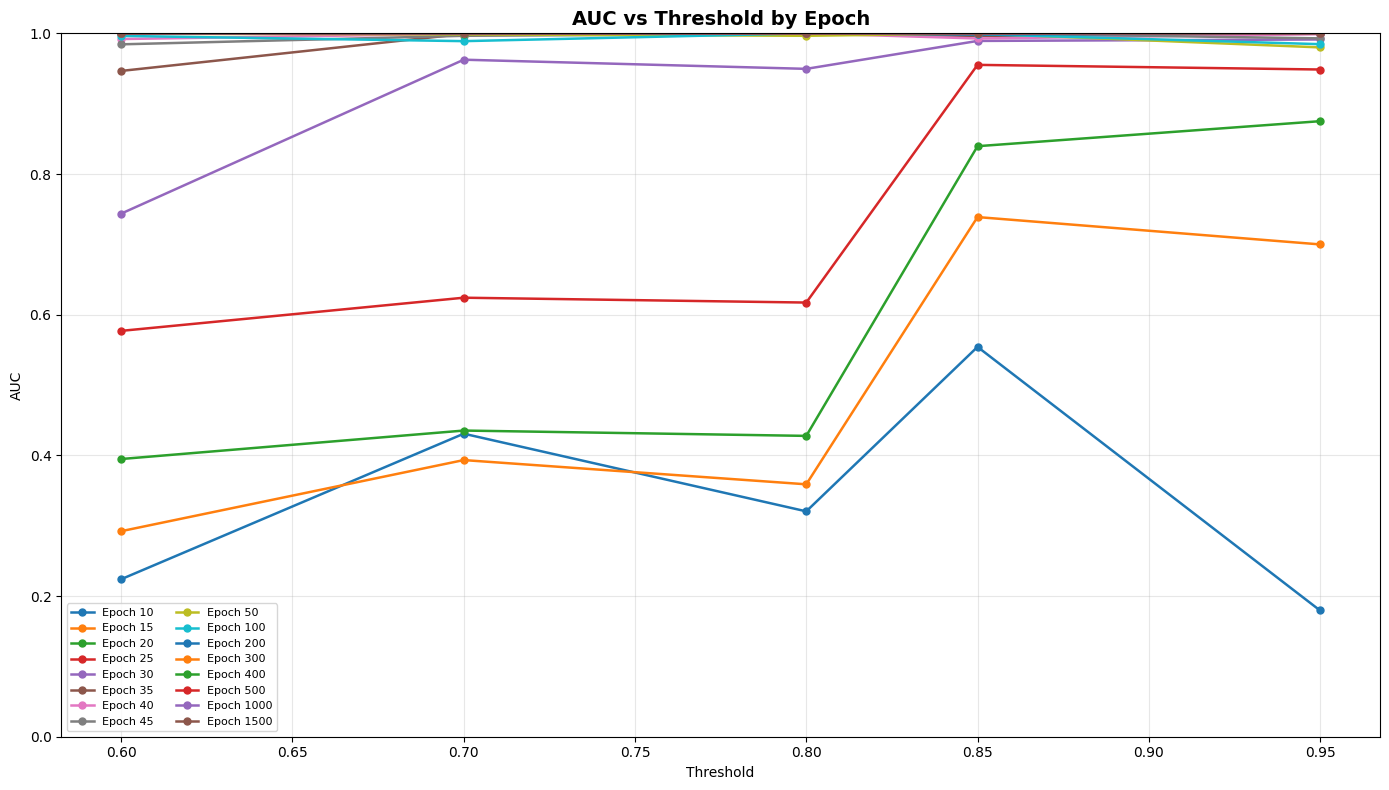

✓ AUC heatmap figure: /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/fft_epochwise_auc_heatmap.png


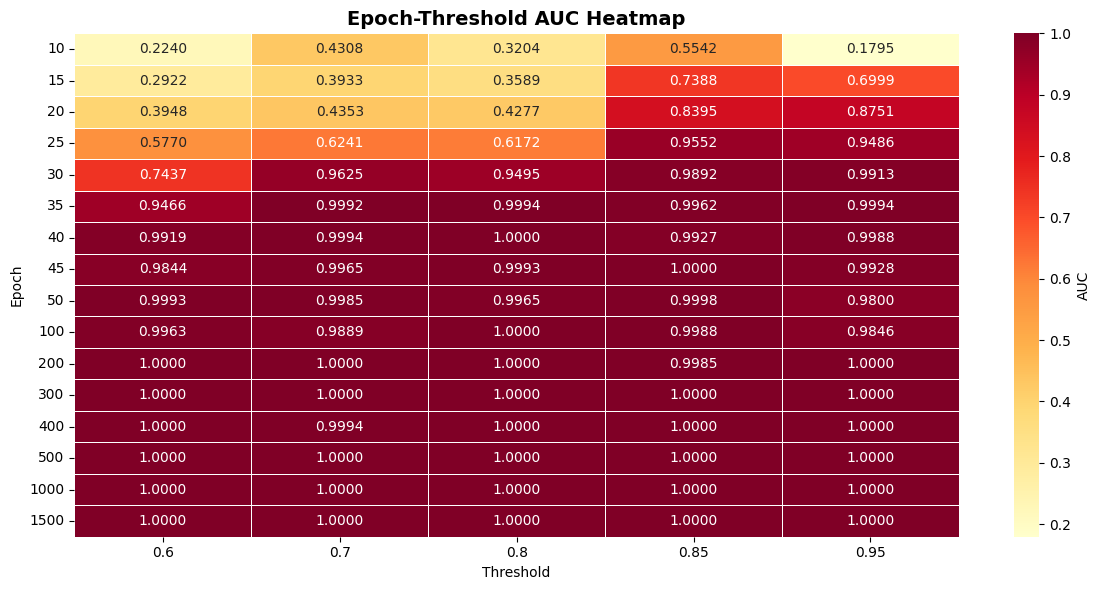


Epoch-wise ROC/AUC visualization complete.



In [63]:
### K.2 Visualize Epoch-Wise ROC/AUC Trends

print("=" * 100)
print("K.2 VISUALIZING EPOCH-WISE ROC/AUC TRENDS")
print("=" * 100)

if 'epoch_auc_df_jk' not in globals() or len(epoch_auc_df_jk) == 0:
    print("No epoch-wise AUC data available. Run K.1 after J.2 training first.")
else:
    # Build publication-view threshold set (aligned with J.6b if available).
    excluded_thresholds_jk = EXCLUDED_THRESHOLDS_J6B if 'EXCLUDED_THRESHOLDS_J6B' in globals() else []

    def _is_excluded_threshold_jk(th_value):
        return any(np.isclose(float(th_value), float(ex)) for ex in excluded_thresholds_jk)

    display_thresholds_jk = [
        float(th) for th in THRESHOLDS_PER_MODEL
        if not _is_excluded_threshold_jk(th)
    ]
    if len(display_thresholds_jk) == 0:
        display_thresholds_jk = [float(th) for th in THRESHOLDS_PER_MODEL]

    epoch_roc_plot_df_jk = epoch_roc_df_jk[epoch_roc_df_jk['threshold'].isin(display_thresholds_jk)].copy()
    epoch_auc_plot_df_jk = epoch_auc_df_jk[epoch_auc_df_jk['threshold'].isin(display_thresholds_jk)].copy()

    # 1) ROC overlays per epoch (each subplot compares thresholds)
    n_epochs_jk = len(milestone_epochs_jk)
    n_cols_jk = 4
    n_rows_jk = int(np.ceil(n_epochs_jk / n_cols_jk))

    fig1, axes = plt.subplots(n_rows_jk, n_cols_jk, figsize=(24, 5 * n_rows_jk), squeeze=False)
    axes_flat_jk = axes.flatten()

    threshold_palette_jk = sns.color_palette("tab10", n_colors=len(display_thresholds_jk))
    threshold_color_map_jk = {
        float(threshold): threshold_palette_jk[idx]
        for idx, threshold in enumerate(display_thresholds_jk)
    }

    for idx_ep, epoch in enumerate(milestone_epochs_jk):
        ax = axes_flat_jk[idx_ep]

        for threshold in display_thresholds_jk:
            threshold_f = float(threshold)
            roc_slice_jk = epoch_roc_plot_df_jk[
                (np.isclose(epoch_roc_plot_df_jk['threshold'], threshold_f)) &
                (epoch_roc_plot_df_jk['epoch'] == epoch)
            ]
            if len(roc_slice_jk) == 0:
                continue

            auc_val_jk = roc_slice_jk['auc'].iloc[0]
            ax.plot(
                roc_slice_jk['fpr'].values,
                roc_slice_jk['tpr'].values,
                color=threshold_color_map_jk[threshold_f],
                linewidth=1.8,
                label=f"T={threshold_f:.2f} (AUC={auc_val_jk:.3f})"
            )

        ax.plot([0, 1], [0, 1], 'k--', linewidth=1.1, alpha=0.6)
        ax.set_title(f"Epoch {epoch}", fontsize=11, fontweight='bold')
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.grid(True, alpha=0.3)
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])
        ax.legend(loc='lower right', fontsize=7)

    for idx_extra in range(n_epochs_jk, len(axes_flat_jk)):
        axes_flat_jk[idx_extra].axis('off')

    plt.suptitle("Epoch-wise ROC Curves (Publication View)", fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])

    roc_overlay_plot_path_jk = f"{_func(MAIN_BEARING)}_epochwise_roc_overlays_per_epoch.png"
    plt.savefig(roc_overlay_plot_path_jk, dpi=300, bbox_inches='tight')
    print(f"✓ ROC overlay figure: {roc_overlay_plot_path_jk}")
    plt.show()

    # 2) AUC vs threshold per epoch
    fig2 = plt.figure(figsize=(14, 8))

    for epoch in milestone_epochs_jk:
        auc_slice_jk = epoch_auc_plot_df_jk[
            (epoch_auc_plot_df_jk['epoch'] == epoch) &
            (epoch_auc_plot_df_jk['status'] == 'ok')
        ].sort_values('threshold')

        if len(auc_slice_jk) == 0:
            continue

        plt.plot(
            auc_slice_jk['threshold'].values,
            auc_slice_jk['auc'].values,
            marker='o',
            linewidth=1.8,
            markersize=5,
            label=f"Epoch {epoch}"
        )

    plt.title("AUC vs Threshold by Epoch", fontsize=14, fontweight='bold')
    plt.xlabel("Threshold")
    plt.ylabel("AUC")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.ylim([0, 1])
    plt.tight_layout()

    auc_trend_plot_path_jk = f"{_func(MAIN_BEARING)}_epochwise_auc_vs_threshold.png"
    plt.savefig(auc_trend_plot_path_jk, dpi=300, bbox_inches='tight')
    print(f"✓ AUC trend figure: {auc_trend_plot_path_jk}")
    plt.show()

    # 3) AUC heatmap (epoch x threshold)
    auc_ok_jk = epoch_auc_plot_df_jk[epoch_auc_plot_df_jk['status'] == 'ok'].copy()
    auc_heatmap_jk = auc_ok_jk.pivot(index='epoch', columns='threshold', values='auc').sort_index()

    fig3 = plt.figure(figsize=(12, 6))
    sns.heatmap(
        auc_heatmap_jk,
        annot=True,
        fmt='.4f',
        cmap='YlOrRd',
        linewidths=0.5,
        cbar_kws={'label': 'AUC'}
    )
    plt.title("Epoch-Threshold AUC Heatmap", fontsize=14, fontweight='bold')
    plt.xlabel("Threshold")
    plt.ylabel("Epoch")
    plt.tight_layout()

    auc_heatmap_plot_path_jk = f"{_func(MAIN_BEARING)}_epochwise_auc_heatmap.png"
    plt.savefig(auc_heatmap_plot_path_jk, dpi=300, bbox_inches='tight')
    print(f"✓ AUC heatmap figure: {auc_heatmap_plot_path_jk}")
    plt.show()

    print("\nEpoch-wise ROC/AUC visualization complete.")
    print()